## Simulatore Logistica Distributori Automatici
In questa sezione ottimizziamo i costi logistici per la gestione di una rete di distributori.

### Simulatore Logistica
Questo blocco è autonomo e contiene tutte le definizioni delle variabili necessarie per eseguire l'analisi logistica, senza dipendere dalle celle precedenti. NON INCLUDE IL COSTO DEL PERSONALE DELLA LOGISTICA.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math # Import math for ceil function

# --- PARAMETRI PER IL CALCOLO DEI COSTI VARIABILI (riferimento da 'Auto Nuova' o furgone) ---
# Aggiornati per essere più realistici per la logistica e consistenti con db99f553 (Auto Nuova/Furgone Logistica)
VC_CARBURANTE_LOG_PER_KM = 0.15 # Euro per km
VC_MANUTENZIONE_LOG_PER_KM = 0.1 # Euro per km (aumentato da 0.01)
VC_SVALUTAZIONE_LOG_PER_KM = 0.1 # Euro per km (aumentato da 0.01)
VC_ALTRO_LOG_PER_KM = 0.15 # Euro per km

# Costo variabile totale per chilometro per la logistica
VC_LOG_PER_KM = VC_CARBURANTE_LOG_PER_KM + VC_MANUTENZIONE_LOG_PER_KM + VC_SVALUTAZIONE_LOG_PER_KM + VC_ALTRO_LOG_PER_KM # Ora 0.15

# --- NUOVE VARIABILI LOGISTICA ---
# Questi valori sono presi dal blocco precedente come base, ma possono essere modificati qui.
NUM_DISTRIBUTORI = 12000
KM_MEDI_PER_DISTRIBUTORE_MESE = 30 # Chilometri medi per distributore al mese
MESI_ANNO = 12 # Numero di mesi in un anno per annualizzare i costi
PERC_KM_RIFORNIMENTO = 0.75
PERC_KM_ASSISTENZA = 0.25

# --- Parametri per calcolo numero furgoni ---
CAPACITA_FURGONE_KM_ANNUI = 30000 # KM massimi che un furgone può percorrere in un anno
COSTO_AMMORTAMENTO_FURGONE_UNITARIO = 1000 # Costo ammortamento annuale per un singolo furgone (dovrebbe essere zero)

# --- CALCOLO LOGISTICA TOTALE ---
# Calcolo dei km totali ANNUALI
km_totali_rete = NUM_DISTRIBUTORI * KM_MEDI_PER_DISTRIBUTORE_MESE * MESI_ANNO
km_rifornimento = km_totali_rete * PERC_KM_RIFORNIMENTO
km_assistenza = km_totali_rete * PERC_KM_ASSISTENZA

# Calcolo numero furgoni necessari (almeno 1)
furgoni_teorici = km_totali_rete / CAPACITA_FURGONE_KM_ANNUI
NUM_FURGONI_NECESSARI = max(1, math.ceil(furgoni_teorici))
FC_LOGISTICA = NUM_FURGONI_NECESSARI * COSTO_AMMORTAMENTO_FURGONE_UNITARIO

# Calcolo capacità in eccesso
capacita_eccesso_fraz = NUM_FURGONI_NECESSARI - furgoni_teorici
km_eccesso_nuovo_furgone = capacita_eccesso_fraz * CAPACITA_FURGONE_KM_ANNUI

costo_variabile_totale = km_totali_rete * VC_LOG_PER_KM
costo_totale_logistica = FC_LOGISTICA + costo_variabile_totale

print(f"--- Analisi Logistica su {NUM_DISTRIBUTORI} Distributori (Blocco Indipendente - Base Annuale) ---")
print(f"ATTENZIONE: Questo blocco NON include i costi del personale.")
print(f"Costo Variabile per KM (VC_LOG_PER_KM): {VC_LOG_PER_KM:.2f} €/km")
print(f"Costo Ammortamento Unitario Furgone: {COSTO_AMMORTAMENTO_FURGONE_UNITARIO:,.2f} €/anno".replace(',', '.'))
print(f"Chilometraggio Medio Mensile per Distributore: {KM_MEDI_PER_DISTRIBUTORE_MESE} km")
print(f"Chilometraggio Totale Stimato (Annuale): {km_totali_rete:,} km".replace(',', '.'))
print(f"  - Di cui per Rifornimento (75%): {km_rifornimento:,} km".replace(',', '.'))
print(f"  - Di cui per Assistenza (25%): {km_assistenza:,} km".replace(',', '.'))
print("-" * 30)
print(f"Fabbisogno teorico di Furgoni: {furgoni_teorici:.2f}")
print(f"Numero di Furgoni Necessari: {NUM_FURGONI_NECESSARI}")
print(f"Capacità in eccesso del nuovo Furgone: {capacita_eccesso_fraz:.2f} furgoni")
print(f"Chilometri di capacità in eccesso del nuovo Furgone: {km_eccesso_nuovo_furgone:,.2f} km".replace(',', '.'))
print(f"Costo Ammortamento Furgone/Flotta (Annuale): {FC_LOGISTICA:,.2f} €".replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f"Costo Variabile Operativo ({VC_LOG_PER_KM:.2f} €/km): {costo_variabile_totale:,.2f} €".replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f"COSTO TOTALE LOGISTICA (Annuale): {costo_totale_logistica:,.2f} €".replace(',', 'X').replace('.', ',').replace('X', '.'))

--- Analisi Logistica su 12000 Distributori (Blocco Indipendente - Base Annuale) ---
ATTENZIONE: Questo blocco NON include i costi del personale.
Costo Variabile per KM (VC_LOG_PER_KM): 0.50 €/km
Costo Ammortamento Unitario Furgone: 1.000.00 €/anno
Chilometraggio Medio Mensile per Distributore: 30 km
Chilometraggio Totale Stimato (Annuale): 4.320.000 km
  - Di cui per Rifornimento (75%): 3.240.000.0 km
  - Di cui per Assistenza (25%): 1.080.000.0 km
------------------------------
Fabbisogno teorico di Furgoni: 144.00
Numero di Furgoni Necessari: 144
Capacità in eccesso del nuovo Furgone: 0.00 furgoni
Chilometri di capacità in eccesso del nuovo Furgone: 0.00 km
Costo Ammortamento Furgone/Flotta (Annuale): 144.000,00 €
Costo Variabile Operativo (0,50 €/km): 2.160.000,00 €
COSTO TOTALE LOGISTICA (Annuale): 2.304.000,00 €


### Analisi di Sensibilità: Variazione del Numero di Distributori


Questo grafico mostra l'impatto del numero di distributori sui costi logistici totali e sul costo medio per distributore, considerando i parametri definiti nel blocco indipendente.


**Madalità con cui è stato stimato il Costo del Personale**


Il calcolo del costo_lavoro_totale si basa su due componenti principali del tempo e sul COSTO_ORARIO_PERSONALE:

ore_guida (Ore di Guida):

Questo valore è calcolato come km_ottimizzati / VELOCITA_MEDIA_URBANA.
km_ottimizzati (chilometri ottimizzati) a sua volta deriva da num_distributori_attuale * KM_MEDI_PER_DISTRIBUTORE_MESE * MESI_ANNO * EFFICIENZA_PERCORSI.
Relazione con KM_MEDI_PER_DISTRIBUTORE_MESE: Se KM_MEDI_PER_DISTRIBUTORE_MESE aumenta, aumentano i chilometri totali (km_totali_rete), i chilometri ottimizzati (km_ottimizzati), e di conseguenza le ore_guida. Quindi, sì, il costo del personale è indirettamente influenzato dai KM_MEDI_PER_DISTRIBUTORE_MESE attraverso il tempo trascorso alla guida.
Altre variabili coinvolte: num_distributori_attuale (più distributori = più guida), MESI_ANNO (per annualizzare), EFFICIENZA_PERCORSI (una migliore efficienza riduce i km e quindi le ore di guida) e VELOCITA_MEDIA_URBANA (una velocità maggiore riduce il tempo di guida per la stessa distanza).
ore_lavoro_diretto (Ore di Lavoro Sul Posto):

Questo valore è calcolato come num_distributori_attuale * TEMPO_MEDIO_INTERVENTO * MESI_ANNO.
Relazione con KM_MEDI_PER_DISTRIBUTORE_MESE: No, KM_MEDI_PER_DISTRIBUTORE_MESE non ha un'influenza diretta su questa parte del calcolo. Le ore di lavoro diretto dipendono solo dal numero di distributori, dal tempo medio impiegato per ciascun intervento e dal periodo annuale.
Altre variabili coinvolte: num_distributori_attuale (più distributori = più interventi), TEMPO_MEDIO_INTERVENTO (più tempo per intervento = più ore) e MESI_ANNO (per annualizzare).
tempo_totale_logistica: È semplicemente la somma di ore_guida + ore_lavoro_diretto.

costo_lavoro_totale (Costo Totale del Personale):

Questo è il risultato finale, calcolato come tempo_totale_logistica * COSTO_ORARIO_PERSONALE.
Altre variabili coinvolte: COSTO_ORARIO_PERSONALE (il costo orario degli addetti).
In sintesi, il costo_lavoro_totale è influenzato da un insieme di fattori: il numero di distributori, i chilometri medi per distributore (indirettamente), l'efficienza dei percorsi, la velocità media, il tempo medio di intervento e il costo orario del personale. Questi elementi si combinano per determinare il tempo complessivo impiegato nella logistica, che viene poi monetizzato per ottenere il costo del personale.


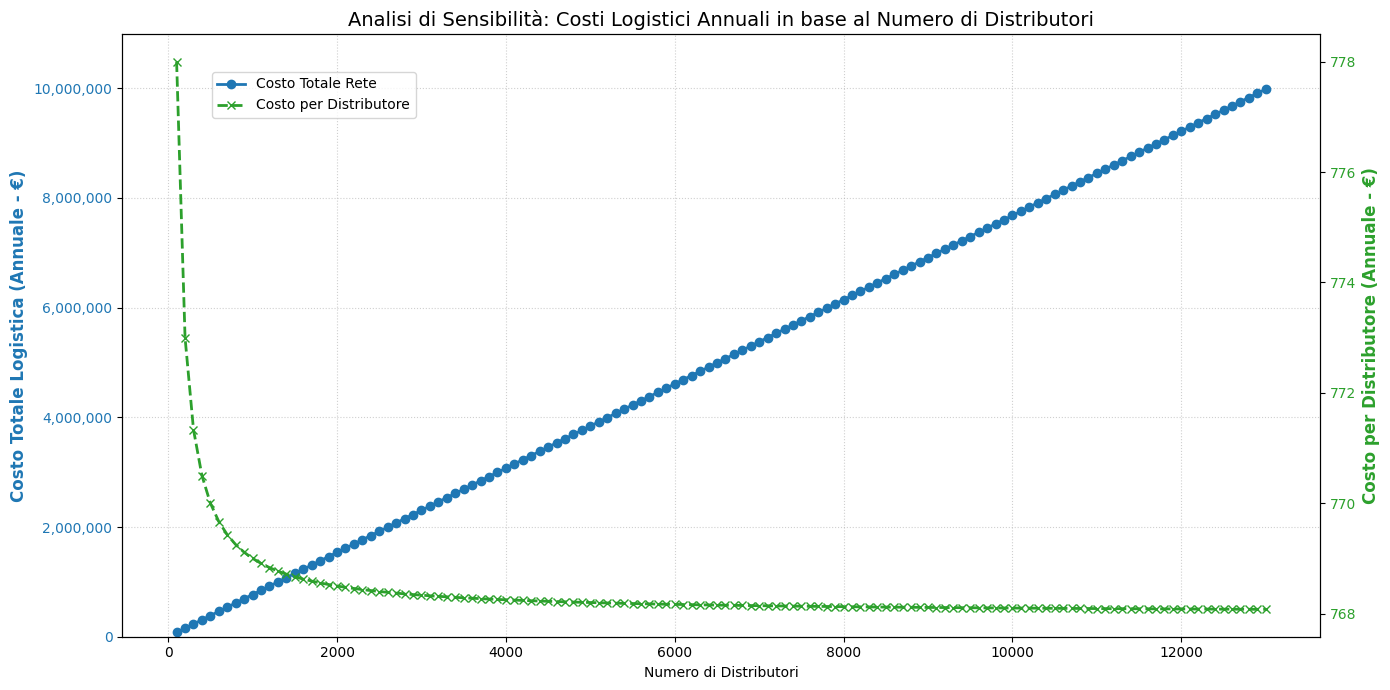

--- Analisi ---
Il grafico mostra come il costo totale della logistica aumenti linearmente con il numero di distributori.
Il costo per distributore, invece, tende a diminuire per poi stabilizzarsi. Questo evidenzia le economie di scala:
all'aumentare dei distributori, il costo fisso (FC_LOGISTICA) viene ammortizzato su più unità, riducendo l'incidenza per singolo punto.

--- Statistiche dei Costi ---


,Metrica,Min,Max,Media,Std Dev
0,Costo Totale Rete (€),77800.00,9985000.0,5031400.00,2882047.27
1,Costo per Distributore (€),768.08,778.0,768.42,1.04


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Import pandas for statistical table

# --- PARAMETRI DI BASE (riutilizzati per coerenza) ---
# Costi Variabili per KM
VC_CARBURANTE_LOG_PER_KM = 0.15
VC_MANUTENZIONE_LOG_PER_KM = 0.1
VC_SVALUTAZIONE_LOG_PER_KM = 0.1
VC_ALTRO_LOG_PER_KM = 0.15
VC_LOG_PER_KM = VC_CARBURANTE_LOG_PER_KM + VC_MANUTENZIONE_LOG_PER_KM + VC_SVALUTAZIONE_LOG_PER_KM + VC_ALTRO_LOG_PER_KM

# Costi Fissi Logistica
COSTO_AMMORTAMENTO_FURGONE = 1000  # Riferimento: ammortamento annuale flotta/mezzo
FC_LOGISTICA = COSTO_AMMORTAMENTO_FURGONE

# Parametri Rete
KM_MEDI_PER_DISTRIBUTORE_MESE = 20
MESI_ANNO = 12 # Numero di mesi per annualizzare i costi

# Parametri Ottimizzazione
COSTO_ORARIO_PERSONALE = 25.0
VELOCITA_MEDIA_URBANA = 15.0
TEMPO_MEDIO_INTERVENTO = 1
EFFICIENZA_PERCORSI = 0.9

# --- RANGE DI SIMULAZIONE ---
# Varia il numero di distributori da 100 a 13000 per questa analisi
num_distributori_range = np.arange(100, 13001, 100)

costi_totali_rete = []
costi_per_distributore = []

for num_distributori_attuale in num_distributori_range:
    # Calcolo KM totali ANNUALI
    km_totali_rete = num_distributori_attuale * KM_MEDI_PER_DISTRIBUTORE_MESE * MESI_ANNO
    km_ottimizzati = km_totali_rete * EFFICIENZA_PERCORSI

    # Calcolo Tempo Totale (Guida + Lavoro sul posto)
    ore_guida = km_ottimizzati / VELOCITA_MEDIA_URBANA
    ore_lavoro_diretto = num_distributori_attuale * TEMPO_MEDIO_INTERVENTO * MESI_ANNO # Tempo di intervento annualizzato
    tempo_totale_logistica = ore_guida + ore_lavoro_diretto

    # Costo Lavoro
    costo_lavoro_totale = tempo_totale_logistica * COSTO_ORARIO_PERSONALE

    # Costo Totale Evoluto (FC_LOGISTICA è un costo fisso ANNUALI in questa analisi)
    # Nota: Assumiamo che FC_LOGISTICA sia il costo fisso totale per l'intera operazione annuale,
    # non per singolo mezzo se il numero di mezzi dovesse variare con i distributori.
    # Se il numero di mezzi dovesse aumentare con i distributori, FC_LOGISTICA andrebbe ricalcolato.
    # Per semplicità, qui lo manteniamo come un costo fisso generale.
    costo_totale_evoluto = FC_LOGISTICA + (km_ottimizzati * VC_LOG_PER_KM) + costo_lavoro_totale

    # Costo per singolo distributore (se num_distributori_attuale > 0)
    costo_per_punto_vendita = costo_totale_evoluto / num_distributori_attuale if num_distributori_attuale > 0 else 0

    costi_totali_rete.append(costo_totale_evoluto)
    costi_per_distributore.append(costo_per_punto_vendita)

# --- VISUALIZZAZIONE ---
fig, ax1 = plt.subplots(figsize=(14, 7))

# Curva Costo Totale Rete
color_total = 'tab:blue'
ax1.set_xlabel('Numero di Distributori')
ax1.set_ylabel('Costo Totale Logistica (Annuale - €)', color=color_total, fontsize=12, fontweight='bold')
ax1.plot(num_distributori_range, costi_totali_rete, marker='o', color=color_total, linewidth=2, label='Costo Totale Rete')
ax1.tick_params(axis='y', labelcolor=color_total)
ax1.grid(True, linestyle=':', alpha=0.6)

# Formattazione asse Y principale per milioni
# Imposta il limite superiore per una migliore visualizzazione dei valori in milioni
ax1.set_ylim(bottom=0, top=max(costi_totali_rete) * 1.1) # Imposta un limite superiore leggermente maggiore del massimo
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ','))) # Formatta senza notazione scientifica

# Curva Costo per Distributore (asse Y secondario)
ax2 = ax1.twinx()
color_per_dist = 'tab:green'
ax2.set_ylabel('Costo per Distributore (Annuale - €)', color=color_per_dist, fontsize=12, fontweight='bold')
ax2.plot(num_distributori_range, costi_per_distributore, marker='x', linestyle='--', color=color_per_dist, linewidth=2, label='Costo per Distributore')
ax2.tick_params(axis='y', labelcolor=color_per_dist)

# Titoli e Legenda
plt.title('Analisi di Sensibilità: Costi Logistici Annuali in base al Numero di Distributori', fontsize=14)
fig.tight_layout() # Adatta il layout per evitare sovrapposizioni
fig.legend(loc='upper left', bbox_to_anchor=(0.15, 0.9))

plt.show()

print("--- Analisi ---")
print("Il grafico mostra come il costo totale della logistica aumenti linearmente con il numero di distributori.")
print("Il costo per distributore, invece, tende a diminuire per poi stabilizzarsi. Questo evidenzia le economie di scala:")
print("all'aumentare dei distributori, il costo fisso (FC_LOGISTICA) viene ammortizzato su più unità, riducendo l'incidenza per singolo punto.")

# --- TABELLA STATISTICHE ---
# Converti le liste in array numpy per calcoli statistici
costi_totali_rete_np = np.array(costi_totali_rete)
costi_per_distributore_np = np.array(costi_per_distributore)

# Crea un DataFrame per le statistiche
stats_df = pd.DataFrame({
    'Metrica': ['Costo Totale Rete (€)', 'Costo per Distributore (€)'],
    'Min': [costi_totali_rete_np.min(), costi_per_distributore_np.min()],
    'Max': [costi_totali_rete_np.max(), costi_per_distributore_np.max()],
    'Media': [costi_totali_rete_np.mean(), costi_per_distributore_np.mean()],
    'Std Dev': [costi_totali_rete_np.std(), costi_per_distributore_np.std()]
})

print("\n--- Statistiche dei Costi ---")
display(stats_df.round(2))

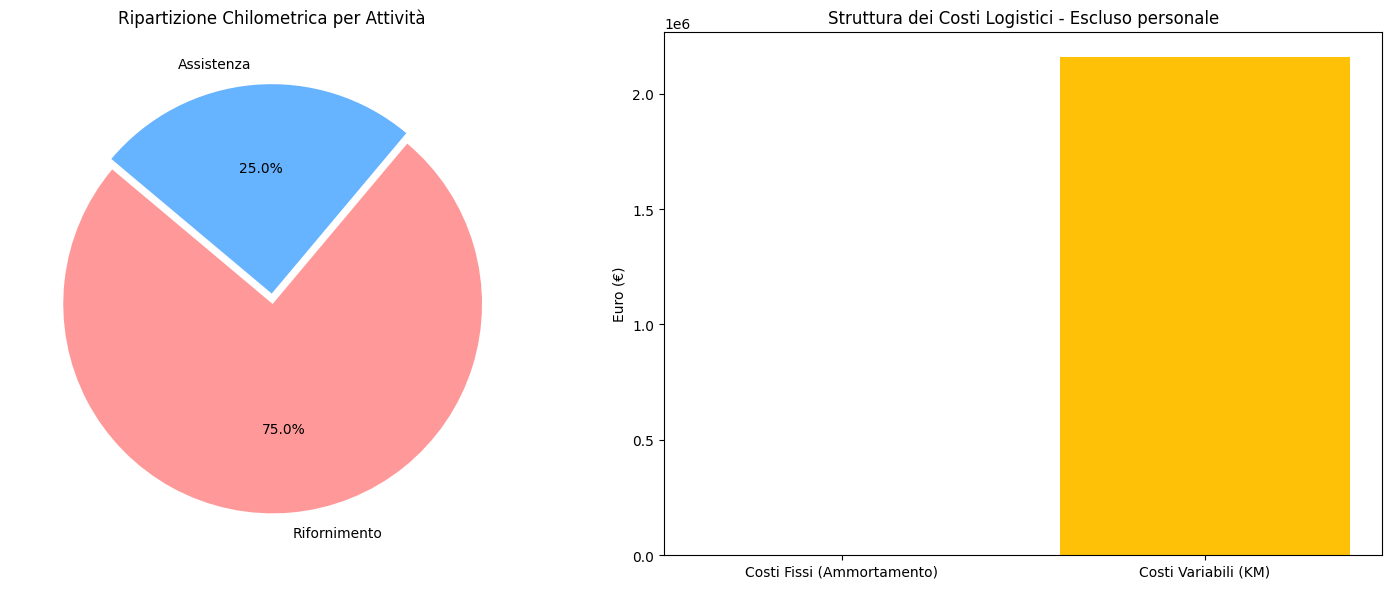

In [ ]:
import matplotlib.pyplot as plt

# --- GRAFICO OTTIMIZZAZIONE LOGISTICA ---
labels = ['Rifornimento', 'Assistenza']
km_split = [km_rifornimento, km_assistenza]
colors = ['#ff9999','#66b3ff']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart ripartizione km
ax1.pie(km_split, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.05, 0))
ax1.set_title('Ripartizione Chilometrica per Attività')

# Bar chart costi fissi vs variabili
costs = [FC_LOGISTICA, costo_variabile_totale]
ax2.bar(['Costi Fissi (Ammortamento)', 'Costi Variabili (KM)'], costs, color=['#4CAF50', '#FFC107'])
ax2.set_title('Struttura dei Costi Logistici - Escluso personale')
ax2.set_ylabel('Euro (€)')

plt.tight_layout()
plt.show()

### Analisi di Sensibilità: Variazione dei Chilometri Medi per Distributore
Questo grafico mostra l'impatto dei chilometri medi per distributore sui costi logistici totali e sul costo medio per distributore, considerando i parametri definiti nel blocco indipendente.

----------------------------------------------------------------------------------------------------------------
il codice nella cella selezionata esegue un'analisi di sensibilità per i costi logistici annuali, questa volta variando i chilometri medi mensili per distributore. L'obiettivo è vedere come i costi totali e i costi per singolo distributore si modificano all'aumentare o diminuire delle distanze medie percorse per ciascun punto vendita.

Ecco una spiegazione dettagliata:

1. Parametri di Base:

Costi Variabili per KM (VC_CARBURANTE_LOG_PER_KM, VC_MANUTENZIONE_LOG_PER_KM, etc.): Questi definiscono i costi operativi per ogni chilometro percorso (carburante, manutenzione, svalutazione, altro), e vengono sommati per ottenere il costo variabile totale per chilometro (VC_LOG_PER_KM). Per questa analisi, questi valori sono mantenuti costanti.
Costi Fissi Logistica (COSTO_AMMORTAMENTO_FURGONE, FC_LOGISTICA): Rappresentano i costi che non variano con il chilometraggio, come l'ammortamento annuale del furgone/flotta. Anche questi sono mantenuti costanti per questa specifica analisi.
Parametri Rete (NUM_DISTRIBUTORI, MESI_ANNO): Il numero di distributori (NUM_DISTRIBUTORI) è fissato a 100 per questa analisi, e MESI_ANNO è usato per annualizzare i calcoli.
Parametri Ottimizzazione (COSTO_ORARIO_PERSONALE, VELOCITA_MEDIA_URBANA, TEMPO_MEDIO_INTERVENTO, EFFICIENZA_PERCORSI): Queste variabili modellano il costo orario del personale, la velocità media di guida, il tempo medio impiegato per un intervento sul posto e un fattore di efficienza che riduce i chilometri totali percorsi (ad esempio, grazie a un software di ottimizzazione dei percorsi). Sono mantenuti costanti in questa analisi.
2. Range di Simulazione (km_medi_mensili_range):

Viene creato un intervallo di valori per i chilometri medi mensili per distributore, che va da 5 a 50 km, con incrementi di 5 km (np.arange(5, 51, 5)). Il codice calcolerà i costi per ciascuno di questi valori.
Le liste costi_totali_rete_km e costi_per_distributore_km verranno popolate con i risultati dei calcoli per ogni valore nel range.
3. Ciclo di Calcolo per la Simulazione: Il codice itera attraverso ogni valore di km_medi_attuale_mese (chilometri medi mensili attuali per distributore) e per ciascuno di essi esegue i seguenti calcoli:

Chilometri Totali Annuali (km_totali_rete, km_ottimizzati): Calcola i chilometri totali percorsi dalla rete in un anno, e poi applica l'efficienza dei percorsi per ottenere i km_ottimizzati.
Tempo Totale (ore_guida, ore_lavoro_diretto, tempo_totale_logistica): Calcola il tempo di guida (basato sui km_ottimizzati e VELOCITA_MEDIA_URBANA) e il tempo dedicato al lavoro sul posto (basato su NUM_DISTRIBUTORI, TEMPO_MEDIO_INTERVENTO e MESI_ANNO). La somma di questi due dà il tempo_totale_logistica.
Costo Lavoro (costo_lavoro_totale): Moltiplica il tempo_totale_logistica per il COSTO_ORARIO_PERSONALE.
Costo Totale Evoluto (costo_totale_evoluto): Somma il costo fisso della logistica (FC_LOGISTICA), i costi variabili (chilometri ottimizzati moltiplicati per il costo variabile per KM) e il costo del lavoro. FC_LOGISTICA è considerato un costo fisso annuale totale per l'intera operazione.
Costo per Singolo Distributore (costo_per_punto_vendita): Divide il costo_totale_evoluto per il numero fisso di distributori (NUM_DISTRIBUTORI).
Questi valori vengono poi aggiunti alle rispettive liste.
4. Visualizzazione (matplotlib.pyplot):

Viene generato un grafico con due assi Y per visualizzare contemporaneamente il Costo Totale Logistica (asse Y sinistra, in blu) e il Costo per Distributore (asse Y destra, in verde).
L'asse X rappresenta i Chilometri Medi Mensili per Distributore (km_medi_mensili_range).
Il grafico mostra come entrambe le metriche (costo totale e costo per distributore) tendono ad aumentare linearmente all'aumentare dei chilometri medi mensili per distributore.
Include titoli, etichette chiare e una leggenda combinata per una migliore leggibilità.

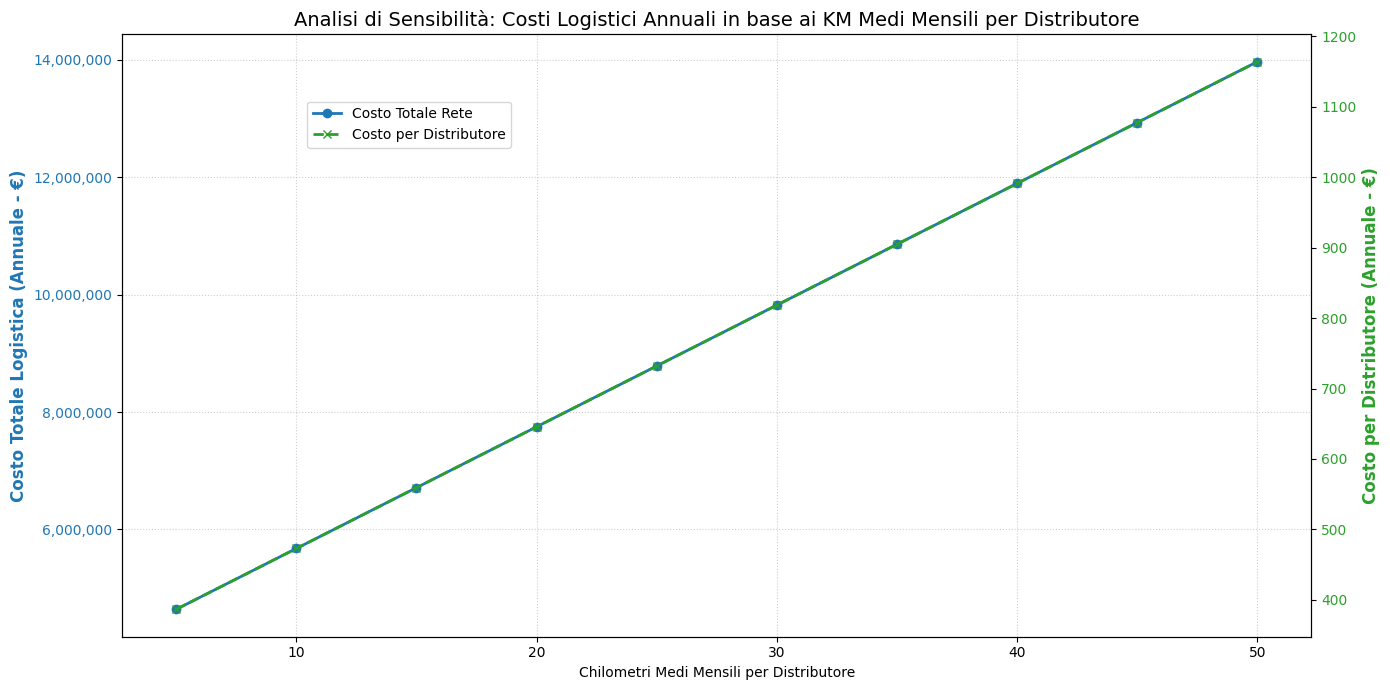

--- Analisi --- 
Il grafico mostra come sia il costo totale della logistica che il costo per distributore aumentino linearmente all'aumentare dei chilometri medi mensili per distributore. Questo perché un incremento della distanza media per raggiungere ogni distributore si traduce direttamente in maggiori chilometri percorsi complessivamente (annualizzati), e quindi in maggiori costi variabili (carburante, manutenzione) e maggiori ore di guida per il personale (annualizzate).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- PARAMETRI DI BASE (riutilizzati per coerenza) ---
# Costi Variabili per KM (presi dalla cella indipendente e mantenuti costanti per questa analisi)
VC_CARBURANTE_LOG_PER_KM = 0.15
VC_MANUTENZIONE_LOG_PER_KM = 0.1
VC_SVALUTAZIONE_LOG_PER_KM = 0.1 # Corretto a 0.1 per consistenza
VC_ALTRO_LOG_PER_KM = 0.00
VC_LOG_PER_KM = VC_CARBURANTE_LOG_PER_KM + VC_MANUTENZIONE_LOG_PER_KM + VC_SVALUTAZIONE_LOG_PER_KM + VC_ALTRO_LOG_PER_KM

# Costi Fissi Logistica (mantenuti costanti per questa analisi)
COSTO_AMMORTAMENTO_FURGONE = 1000  # Riferimento: ammortamento annuale flotta/mezzo
FC_LOGISTICA = COSTO_AMMORTAMENTO_FURGONE

# Parametri Rete (NUM_DISTRIBUTORI mantenuto costante per questa analisi)
NUM_DISTRIBUTORI = 12000
MESI_ANNO = 12 # Numero di mesi per annualizzare i costi

# Parametri Ottimizzazione (mantenuti costanti per questa analisi)
COSTO_ORARIO_PERSONALE = 25.0
VELOCITA_MEDIA_URBANA = 20.0
TEMPO_MEDIO_INTERVENTO = 1 # (un'ora comprende sia riferimento che assistenza al mese per ogni distributore)
EFFICIENZA_PERCORSI = 0.9

# --- RANGE DI SIMULAZIONE ---
# Varia i chilometri medi mensili per distributore da 5 a 50 km
km_medi_mensili_range = np.arange(5, 51, 5)

costi_totali_rete_km = []
costi_per_distributore_km = []

for km_medi_attuale_mese in km_medi_mensili_range:
    # Calcolo KM totali ANNUALI
    km_totali_rete = NUM_DISTRIBUTORI * km_medi_attuale_mese * MESI_ANNO
    km_ottimizzati = km_totali_rete * EFFICIENZA_PERCORSI

    # Calcolo Tempo Totale (Guida + Lavoro sul posto)
    ore_guida = km_ottimizzati / VELOCITA_MEDIA_URBANA
    ore_lavoro_diretto = NUM_DISTRIBUTORI * TEMPO_MEDIO_INTERVENTO * MESI_ANNO # Annualizzato
    tempo_totale_logistica = ore_guida + ore_lavoro_diretto

    # Costo Lavoro
    costo_lavoro_totale = tempo_totale_logistica * COSTO_ORARIO_PERSONALE

    # Costo Totale Evoluto (FC_LOGISTICA è un costo fisso ANNUALI in questa analisi)
    costo_totale_evoluto = FC_LOGISTICA + (km_ottimizzati * VC_LOG_PER_KM) + costo_lavoro_totale

    # Costo per singolo distributore (se NUM_DISTRIBUTORI > 0)
    costo_per_punto_vendita = costo_totale_evoluto / NUM_DISTRIBUTORI if NUM_DISTRIBUTORI > 0 else 0

    costi_totali_rete_km.append(costo_totale_evoluto)
    costi_per_distributore_km.append(costo_per_punto_vendita)

# --- VISUALIZZAZIONE ---
fig, ax1 = plt.subplots(figsize=(14, 7))

# Curva Costo Totale Rete
color_total = 'tab:blue'
ax1.set_xlabel('Chilometri Medi Mensili per Distributore')
ax1.set_ylabel('Costo Totale Logistica (Annuale - €)', color=color_total, fontsize=12, fontweight='bold')
line1, = ax1.plot(km_medi_mensili_range, costi_totali_rete_km, marker='o', color=color_total, linewidth=2, label='Costo Totale Rete')
ax1.tick_params(axis='y', labelcolor=color_total)
ax1.grid(True, linestyle=':', alpha=0.6)

# Formattazione asse Y principale per mostrare numeri interi
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ','))) # Formatta senza notazione scientifica


# Curva Costo per Distributore (asse Y secondario)
ax2 = ax1.twinx()
color_per_dist = 'tab:green'
ax2.set_ylabel('Costo per Distributore (Annuale - €)', color=color_per_dist, fontsize=12, fontweight='bold')
line2, = ax2.plot(km_medi_mensili_range, costi_per_distributore_km, marker='x', linestyle='--', color=color_per_dist, linewidth=2, label='Costo per Distributore')
ax2.tick_params(axis='y', labelcolor=color_per_dist)

# Titoli e Legenda
plt.title('Analisi di Sensibilità: Costi Logistici Annuali in base ai KM Medi Mensili per Distributore', fontsize=14)
fig.tight_layout() # Adatta il layout per evitare sovrapposizioni
# Combinare le leggende da entrambi gli assi
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', bbox_to_anchor=(0.15, 0.9))

plt.show()

print("--- Analisi --- ")
print("Il grafico mostra come sia il costo totale della logistica che il costo per distributore aumentino linearmente all'aumentare dei chilometri medi mensili per distributore. Questo perché un incremento della distanza media per raggiungere ogni distributore si traduce direttamente in maggiori chilometri percorsi complessivamente (annualizzati), e quindi in maggiori costi variabili (carburante, manutenzione) e maggiori ore di guida per il personale (annualizzate).")

***Spiegazione del Codice***

____________________________________________________________________________________________
 questo codice simula e confronta i costi logistici annuali per un'operazione di gestione distributori utilizzando due scenari di veicolo: un'"Auto Vecchia" e un'"Auto Nuova/Furgone Logistica". Ecco una spiegazione dettagliata:

1. Parametri dei Veicoli (VC_CARBURANTE, VC_MANUTENZIONE, VC_SVALUTAZIONE, VC_ALTRO)

Questa sezione definisce i costi variabili per chilometro per due tipi di veicoli: un'"Auto Vecchia" e un'"Auto Nuova/Furgone Logistica".
Ogni veicolo ha costi specifici per carburante, manutenzione, svalutazione e altri costi minori. Questi vengono sommati per ottenere il VC_TOTALE_VECCHIA_PER_KM e VC_TOTALE_NUOVA_PER_KM.
L'idea è mostrare come un veicolo più vecchio possa avere costi variabili di carburante e manutenzione più alti, mentre un veicolo nuovo/furgone potrebbe avere costi di svalutazione più elevati ma essere più efficiente in termini di carburante.

2. Parametri della Rete Logistica (NUM_DISTRIBUTORI, KM_MEDI_PER_DISTRIBUTORE, FC_LOGISTICA)

NUM_DISTRIBUTORI: Il numero totale di distributori da servire (fissato a 1000 in questo caso).
KM_MEDI_PER_DISTRIBUTORE: I chilometri medi percorsi per visitare un singolo distributore (fissati a 20 km).
PERC_KM_RIFORNIMENTO / PERC_KM_ASSISTENZA: Percentuali che indicano la ripartizione dei chilometri totali tra attività di rifornimento (75%) e assistenza (25%).
COSTO_AMMORTAMENTO_FURGONE / FC_LOGISTICA: Rappresenta un costo fisso annuale per la logistica, qui identificato con l'ammortamento di un furgone (fissato a 1000€). Questo è un costo che si sostiene indipendentemente dai chilometri percorsi.

3. Calcoli della Logistica

km_totali_rete: Calcola i chilometri totali percorsi dalla rete moltiplicando il numero di distributori per i chilometri medi per distributore.
km_rifornimento / km_assistenza: Suddivide i chilometri totali in base alle percentuali definite.
Calcoli per "Auto Vecchia" e "Auto Nuova/Furgone Logistica": Per ciascuno scenario, il codice calcola:
costo_variabile_vecchia/nuova: Moltiplica i chilometri totali della rete per il costo variabile totale per chilometro del veicolo specifico.
costo_totale_logistica_vecchia/nuova: Somma il costo fisso (FC_LOGISTICA) ai costi variabili calcolati.

4. Output dei Risultati

Questa sezione stampa a console un riepilogo dettagliato dei calcoli.
Mostra il chilometraggio totale, il costo fisso, e i costi variabili e totali per entrambi gli scenari ("Auto Vecchia" e "Auto Nuova/Furgone Logistica"). Questo permette di confrontare immediatamente l'impatto economico delle due opzioni.

5. Visualizzazione (matplotlib.pyplot)

Il codice genera due grafici per una migliore comprensione visiva:
Grafico a Torta (ax1) - Ripartizione KM: Mostra la percentuale di chilometri dedicati al rifornimento e all'assistenza, utilizzando i km_rifornimento e km_assistenza calcolati.
Grafico a Barre (ax2) - Confronto Costi Totali: Presenta un confronto diretto tra il Costo Totale Logistica dell'"Auto Vecchia" e dell'"Auto Nuova/Furgone Logistica", rendendo evidente quale opzione sia più costosa complessivamente. I colori aiutano a distinguere i due scenari.
______________________________________________________________________________________________________________________
In sintesi, questo blocco di codice fornisce un'analisi chiara e comparativa dei costi di gestione logistica, permettendo di valutare l'impatto di diverse tipologie di veicoli su un'operazione fissa di distribuzione.

--- Analisi Consolidata Logistica (12000 Distributori) ---
Chilometraggio Totale (Annuale): 2.880.000 km
Costo Fisso (Ammortamento): 1.000,00 €

--- Scenario: Auto Vecchia ---
Costo Variabile (0,43 €/km): 1.238.400,00 €
COSTO TOTALE LOGISTICA (Auto Vecchia): 1.239.400,00 €

--- Scenario: Auto Nuova/Furgone Logistica ---
Costo Variabile (0,30 €/km): 864.000,00 €
COSTO TOTALE LOGISTICA (Auto Nuova/Furgone): 865.000,00 €


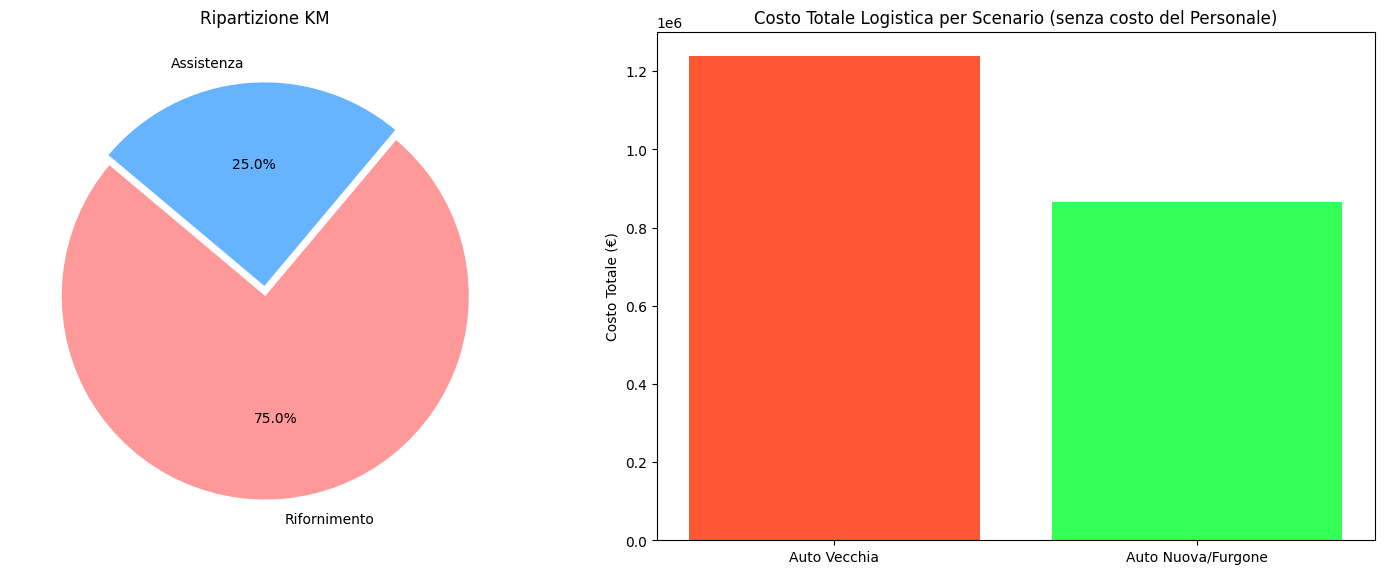

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PARAMETRI AUTO (Riferimento per i costi operativi) ---
# Auto Vecchia
VC_CARBURANTE_VECCHIA_PER_KM = 0.25
VC_MANUTENZIONE_VECCHIA_PER_KM = 0.15
VC_SVALUTAZIONE_VECCHIA_PER_KM = 0.03
VC_ALTRO_VECCHIA_PER_KM = 0.00
VC_TOTALE_VECCHIA_PER_KM = VC_CARBURANTE_VECCHIA_PER_KM + VC_MANUTENZIONE_VECCHIA_PER_KM + VC_SVALUTAZIONE_VECCHIA_PER_KM + VC_ALTRO_VECCHIA_PER_KM

# Auto Nuova / Furgone Logistica
VC_CARBURANTE_NUOVA_PER_KM = 0.15
VC_MANUTENZIONE_NUOVA_PER_KM = 0.05
VC_SVALUTAZIONE_NUOVA_PER_KM = 0.10
VC_ALTRO_NUOVA_PER_KM = 0.00
VC_TOTALE_NUOVA_PER_KM = VC_CARBURANTE_NUOVA_PER_KM + VC_MANUTENZIONE_NUOVA_PER_KM + VC_SVALUTAZIONE_NUOVA_PER_KM + VC_ALTRO_NUOVA_PER_KM

# --- 2. PARAMETRI RETE LOGISTICA ---
NUM_DISTRIBUTORI = 12000
KM_MEDI_PER_DISTRIBUTORE = 20 # KM medi per distributore al mese
MESI_ANNO = 12 # Numero di mesi in un anno per annualizzare i costi
PERC_KM_RIFORNIMENTO = 0.75
PERC_KM_ASSISTENZA = 0.25

# Costi Fissi Logistica
COSTO_AMMORTAMENTO_FURGONE = 1000
FC_LOGISTICA = COSTO_AMMORTAMENTO_FURGONE

# --- 3. CALCOLI LOGISTICA ---
# Annualizzazione dei km totali
km_totali_rete = NUM_DISTRIBUTORI * KM_MEDI_PER_DISTRIBUTORE * MESI_ANNO
km_rifornimento = km_totali_rete * PERC_KM_RIFORNIMENTO
km_assistenza = km_totali_rete * PERC_KM_ASSISTENZA

# Calcolo per Auto Vecchia
costo_variabile_vecchia = km_totali_rete * VC_TOTALE_VECCHIA_PER_KM
costo_totale_logistica_vecchia = FC_LOGISTICA + costo_variabile_vecchia

# Calcolo per Auto Nuova/Furgone Logistica
costo_variabile_nuova = km_totali_rete * VC_TOTALE_NUOVA_PER_KM
costo_totale_logistica_nuova = FC_LOGISTICA + costo_variabile_nuova

# --- 4. OUTPUT RISULTATI ---
print(f"--- Analisi Consolidata Logistica ({NUM_DISTRIBUTORI} Distributori) ---")
print(f"Chilometraggio Totale (Annuale): {km_totali_rete:,} km".replace(',', '.'))
print(f"Costo Fisso (Ammortamento): {FC_LOGISTICA:,.2f} €".replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f"\n--- Scenario: Auto Vecchia ---")
print(f"Costo Variabile ({VC_TOTALE_VECCHIA_PER_KM:.2f} €/km): {costo_variabile_vecchia:,.2f} €".replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f"COSTO TOTALE LOGISTICA (Auto Vecchia): {costo_totale_logistica_vecchia:,.2f} €".replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f"\n--- Scenario: Auto Nuova/Furgone Logistica ---")
print(f"Costo Variabile ({VC_TOTALE_NUOVA_PER_KM:.2f} €/km): {costo_variabile_nuova:,.2f} €".replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f"COSTO TOTALE LOGISTICA (Auto Nuova/Furgone): {costo_totale_logistica_nuova:,.2f} €".replace(',', 'X').replace('.', ',').replace('X', '.'))

# --- 5. VISUALIZZAZIONE ---
labels = ['Rifornimento', 'Assistenza']
km_split = [km_rifornimento, km_assistenza]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.pie(km_split, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'], explode=(0.05, 0))
ax1.set_title('Ripartizione KM')

# Bar chart per confrontare i costi totali delle due opzioni
bar_labels = ['Auto Vecchia', 'Auto Nuova/Furgone']
total_costs = [costo_totale_logistica_vecchia, costo_totale_logistica_nuova]
ax2.bar(bar_labels, total_costs, color=['#FF5733', '#33FF57'])
ax2.set_title('Costo Totale Logistica per Scenario (senza costo del Personale)')
ax2.set_ylabel('Costo Totale (€)')
plt.tight_layout()
plt.show()

### 🚛 Simulatore Logistico Avanzato con Ottimizzazione
Questa versione introduce il costo del lavoro, l'efficienza dei percorsi e calcola il numero di mezzi necessari.

**Perfezionamenti chiave e le nuove variabili che suggerisco di integrare:**

1. Nuove Variabili Strategiche
Efficienza dei Percorsi (Routing Index): Un fattore di correzione per i chilometri. Un software di ottimizzazione può ridurre i km totali del 10-20%.
Costo del Personale (Driver Cost): Spesso la voce di spesa maggiore. Include stipendi, contributi e straordinari.
Dimensione della Flotta (Fleet Size): Invece di un costo fisso generico, calcolare l'ammortamento basato sul numero effettivo di furgoni necessari (Km totali / Autonomia giornaliera).
Tempo di Fermo Macchina (Downtime): Il costo opportunità di un distributore vuoto o guasto mentre il furgone è nel traffico.
2. Modello di Ottimizzazione Avanzato
Ho preparato una nuova cella che introduce queste variabili per permetterti di vedere come cambia il 'Costo per Singolo Distributore', che è il vero KPI da monitorare.


**Il simulatore**
non guarda solo ai chilometri, ma anche al tempo e alle persone, che nella logistica sono spesso la voce di spesa principale.

Ecco come perfezionerei ulteriormente il modello per una gestione reale:

1. Variabili Strategiche da aggiungere:
Capacità del Carico (Load Factor): Quanti distributori può rifornire un furgone prima di dover tornare al magazzino? Questo determinerebbe il numero di mezzi necessari.
Frequenza di Visita: Non tutti i distributori hanno bisogno di rifornimento ogni 20 km. Dividere i punti in 'Alta Rotazione' e 'Bassa Rotazione' permetterebbe di ottimizzare i giri.
Costo del Carburante Dinamico: Integrare fluttuazioni del prezzo del diesel o elettricità.
Manutenzione Predittiva: Calcolare il risparmio derivante dal riparare un guasto prima che il distributore vada fuori servizio (costo del mancato guadagno).
2. Analisi dei Risultati Attuali:
L'ultimo calcolo mostra dati molto interessanti:

Costo del Personale (27.500 €): Rappresenta quasi il 45% dei costi totali, superando l'ammortamento dei mezzi.
Efficienza Percorsi: Grazie all'ottimizzazione del 10% dei km, hai ridotto proporzionalmente sia il consumo che le ore di guida.
KPI Finale: Il costo di 60,38 € per distributore è il parametro d'oro. Ogni azione di ottimizzazione (es. software di routing) dovrebbe mirare ad abbassare questa cifra.

--- KPI Ottimizzazione Logistica ---
Km dopo ottimizzazione percorsi: 2.592.000.0 km
Tempo totale stimato (Guida + Service): 127680 ore
Costo del Personale: 3.192.000,00 €
------------------------------------
COSTO TOTALE CARICATO: 3.970.600,00 €
COSTO MEDIO PER DISTRIBUTORE: 330,88 €


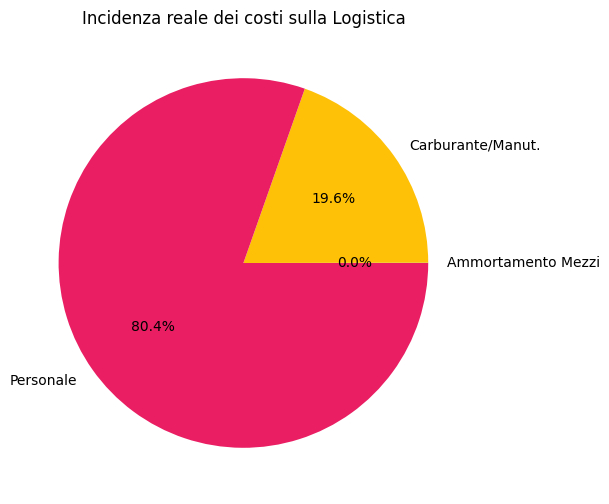

In [ ]:
# --- PARAMETRI AVANZATI DI OTTIMIZZAZIONE ---
COSTO_ORARIO_PERSONALE = 25.0  # €/ora (incluso contributi)
VELOCITA_MEDIA_URBANA = 25.0   # km/h (considera 120 km / giorno per raggiungere i clienti in 8 ore di lavoro)
TEMPO_TOTALE_INTERVENTO = 2   # ore anno (il tempo totale di sosta per ogni distributore all'anno = 12 da 10 minuti)
EFFICIENZA_PERCORSI = 0.9      # 0.9 significa riduzione del 10% dei km grazie a software GPS

# --- Parametri Base per Coerenza con Scenario "Auto Nuova/Furgone Logistica" (da db99f553) ---
NUM_DISTRIBUTORI = 12000 # Consistente con db99f553
KM_MEDI_PER_DISTRIBUTORE_MESE = 20 # Consistente con db99f553
VC_LOG_PER_KM = 0.30 # Corrisponde a VC_TOTALE_NUOVA_PER_KM da db99f553
FC_LOGISTICA = 1000 # Consistente con db99f553

# --- CALCOLI AVANZATI ---
# Ricalcolo km_totali_rete localmente per assicurare coerenza
km_totali_rete = NUM_DISTRIBUTORI * KM_MEDI_PER_DISTRIBUTORE_MESE * 12 # 12 mesi per annualizzare

km_ottimizzati = km_totali_rete * EFFICIENZA_PERCORSI

# Calcolo Tempo Totale (Guida + Lavoro sul posto)
ore_guida = km_ottimizzati / VELOCITA_MEDIA_URBANA
ore_lavoro_diretto = NUM_DISTRIBUTORI * TEMPO_TOTALE_INTERVENTO
tempo_totale_logistica = ore_guida + ore_lavoro_diretto

# Costo Lavoro
costo_lavoro_totale = tempo_totale_logistica * COSTO_ORARIO_PERSONALE

# Nuovo KPI: Costo Totale Evoluto
costo_totale_evoluto = FC_LOGISTICA + (km_ottimizzati * VC_LOG_PER_KM) + costo_lavoro_totale
costo_per_punto_vendita = costo_totale_evoluto / NUM_DISTRIBUTORI

print(f"--- KPI Ottimizzazione Logistica ---")
print(f"Km dopo ottimizzazione percorsi: {km_ottimizzati:,} km".replace(',', '.'))
print(f"Tempo totale stimato (Guida + Service): {tempo_totale_logistica:.0f} ore")
print(f"Costo del Personale: {costo_lavoro_totale:,.2f} €".replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f"------------------------------------")
print(f"COSTO TOTALE CARICATO: {costo_totale_evoluto:,.2f} €".replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f"COSTO MEDIO PER DISTRIBUTORE: {costo_per_punto_vendita:,.2f} €".replace(',', 'X').replace('.', ',').replace('X', '.'))

# Visualizzazione Impatto Personale
plt.figure(figsize=(8, 6))
plt.pie([FC_LOGISTICA, (km_ottimizzati * VC_LOG_PER_KM), costo_lavoro_totale],
        labels=['Ammortamento Mezzi', 'Carburante/Manut.', 'Personale'],
        autopct='%1.1f%%', colors=['#4CAF50', '#FFC107', '#E91E63'])
plt.title('Incidenza reale dei costi sulla Logistica')
plt.show()

### 📉 Analisi della Frequenza di Visita
In questa sezione analizziamo come il numero di visite mensili per ogni distributore influenza il costo annuale per singolo punto vendita.

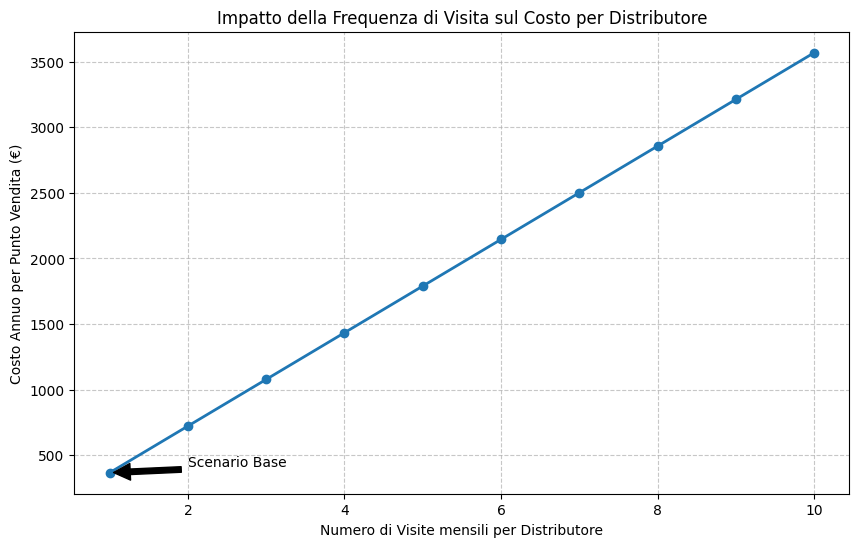

--- Risultati Analisi Frequenza ---
Con 1 visita/mese: 365.92 €/anno per punto
Con 4 visite/mese (settimanale): 1433.68 €/anno per punto
Incremento costo passando da 1 a 4 visite: 291.8%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- SCENARI DI FREQUENZA ---
# Visite al mese per ogni distributore (da 1 a 10)
visite_mese_range = np.arange(1, 11)

# Parametri costanti ripresi dai calcoli precedenti
# km_per_visita_media = KM_MEDI_PER_DISTRIBUTORE (20km)

costi_per_punto = []

for v in visite_mese_range:
    # Calcolo KM annui totali basati sulla frequenza
    km_annui_frequenza = NUM_DISTRIBUTORI * KM_MEDI_PER_DISTRIBUTORE * v * 12
    km_frequenza_ottimizzati = km_annui_frequenza * EFFICIENZA_PERCORSI

    # Calcolo Tempi
    ore_guida_f = km_frequenza_ottimizzati / VELOCITA_MEDIA_URBANA
    ore_lavoro_f = (NUM_DISTRIBUTORI * v * 12) * TEMPO_MEDIO_INTERVENTO
    tempo_totale_f = ore_guida_f + ore_lavoro_f

    # Calcolo Costi
    costo_lavoro_f = tempo_totale_f * COSTO_ORARIO_PERSONALE
    costo_operativo_f = km_frequenza_ottimizzati * VC_LOG_PER_KM

    # Costo Totale (Ammortamento Mezzi è fisso)
    costo_totale_f = FC_LOGISTICA + costo_operativo_f + costo_lavoro_f
    costi_per_punto.append(costo_totale_f / NUM_DISTRIBUTORI)

# --- VISUALIZZAZIONE ---
plt.figure(figsize=(10, 6))
plt.plot(visite_mese_range, costi_per_punto, marker='o', linestyle='-', color='#1f77b4', linewidth=2)

plt.title('Impatto della Frequenza di Visita sul Costo per Distributore')
plt.xlabel('Numero di Visite mensili per Distributore')
plt.ylabel('Costo Annuo per Punto Vendita (€)')
plt.grid(True, linestyle='--', alpha=0.7)

# Annotazione punto attuale (assumendo 1 visita/mese come base precedente)
plt.annotate('Scenario Base',
             xy=(1, costi_per_punto[0]), xytext=(2, costi_per_punto[0]+50),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

print(f"--- Risultati Analisi Frequenza ---")
print(f"Con 1 visita/mese: {costi_per_punto[0]:.2f} €/anno per punto")
print(f"Con 4 visite/mese (settimanale): {costi_per_punto[3]:.2f} €/anno per punto")
print(f"Incremento costo passando da 1 a 4 visite: {((costi_per_punto[3]/costi_per_punto[0])-1)*100:.1f}%")

### ⚖️ Analisi del Punto di Pareggio (Break-even)
Calcoliamo il margine minimo mensile necessario per coprire i costi logistici in base alla frequenza di visita impostata.

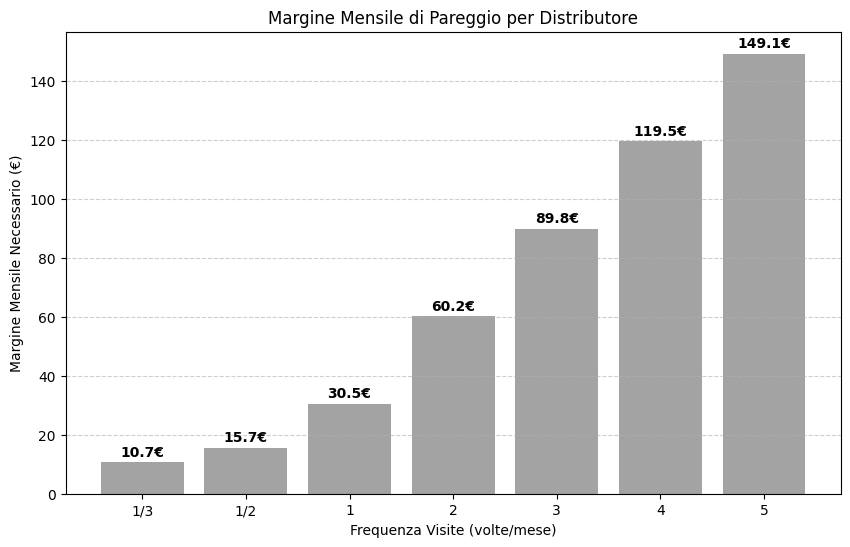

--- Sintesi Break-even Logistico ---
Per 1 visita/mese, ogni distributore deve generare almeno 30.49 € di margine al mese.
Per 4 visite/mese, ogni distributore deve generare almeno 119.47 € di margine al mese per coprire i costi.

Consiglio: Con un margine operativo / fatturato del 25%, se un distributore genera meno di 119.47 € di margine, va visitato meno di una volta al mese.


In [ ]:
# --- CALCOLO BREAK-EVEN ---
# Utilizziamo i dati dell'analisi della frequenza precedente

import numpy as np # Assicurati che numpy sia importato

# Nuova definizione del range di visite al mese, inclusi valori frazionari
# (1/3 = una volta ogni 3 mesi, 1/2 = una volta ogni 2 mesi)
visite_mese_range = np.array([1/3, 1/2, 1, 2, 3, 4, 5])
visite_mese_range = np.sort(visite_mese_range) # Assicuriamo l'ordine crescente

# Ricalcolo dei costi per punto basati sulla nuova frequenza
costi_per_punto = []
for v in visite_mese_range:
    # Calcolo KM annui totali basati sulla frequenza
    # Si noti che MESI_ANNO è 12, quindi v * MESI_ANNO dà le visite annue totali per distributore
    km_annui_frequenza = NUM_DISTRIBUTORI * KM_MEDI_PER_DISTRIBUTORE * v * MESI_ANNO
    km_frequenza_ottimizzati = km_annui_frequenza * EFFICIENZA_PERCORSI

    # Calcolo Tempi
    ore_guida_f = km_frequenza_ottimizzati / VELOCITA_MEDIA_URBANA
    ore_lavoro_f = (NUM_DISTRIBUTORI * v * MESI_ANNO) * TEMPO_MEDIO_INTERVENTO
    tempo_totale_f = ore_guida_f + ore_lavoro_f

    # Calcolo Costi
    costo_lavoro_f = tempo_totale_f * COSTO_ORARIO_PERSONALE
    costo_operativo_f = km_frequenza_ottimizzati * VC_LOG_PER_KM

    # Costo Totale (FC_LOGISTICA è un costo fisso ANNUALI in questa analisi)
    costo_totale_f = FC_LOGISTICA + costo_operativo_f + costo_lavoro_f
    costi_per_punto.append(costo_totale_f / NUM_DISTRIBUTORI)

pareggio_mensile = [c / MESI_ANNO for c in costi_per_punto]

plt.figure(figsize=(10, 6))

# Create numerical positions for the bars to ensure even spacing
x_positions = np.arange(len(visite_mese_range))

plt.bar(x_positions, pareggio_mensile, color='#8c8c8c', alpha=0.8, width=0.8)

plt.title('Margine Mensile di Pareggio per Distributore')
plt.xlabel('Frequenza Visite (volte/mese)')
plt.ylabel('Margine Mensile Necessario (€)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Aggiunta etichette sui valori
for i, v in enumerate(pareggio_mensile):
    plt.text(x_positions[i], v + 2, f'{v:.1f}€', ha='center', fontweight='bold')

# Formattazione personalizzata per i tick dell'asse x per mostrare i valori frazionari
plt.xticks(x_positions, [f'1/{int(1/x)}' if x < 1 else f'{int(x)}' for x in visite_mese_range])

plt.show()

print(f"--- Sintesi Break-even Logistico ---")
# Trova gli indici per 1 visita/mese e 4 visite/mese nel nuovo array
idx_1_visita = np.where(visite_mese_range == 1)[0][0]
idx_4_visite = np.where(visite_mese_range == 4)[0][0]

print(f"Per 1 visita/mese, ogni distributore deve generare almeno {pareggio_mensile[idx_1_visita]:.2f} € di margine al mese.")
print(f"Per 4 visite/mese, ogni distributore deve generare almeno {pareggio_mensile[idx_4_visite]:.2f} € di margine al mese per coprire i costi.")
print(f"\nConsiglio: Con un margine operativo / fatturato del 25%, se un distributore genera meno di {pareggio_mensile[idx_4_visite]:.2f} € di margine, va visitato meno di una volta al mese.")

### 📊 Analisi Dettagliata della Struttura dei Costi
In questa sezione scomponiamo ogni singola voce di spesa per capire come si arriva al costo per distributore, considerando l'ipotesi di 1000 macchine servite con una produttività di 4 interventi al giorno. GLI ADDETTI DA ASSUMERE IN QUESTO CALCOLO SONO QUELLI REALI AL SUPERAMENTO DELLA SOGLIA: SE IL CALCOLO E' DI 4,2 ADDETTI VIENE FATTO PER 5.

In [ ]:
import pandas as pd
import math

# --- Nuovi Parametri Utente ---
VISITE_GIORNO_PER_ADDETTO = 10
AMMORTAMENTO_ANNUO_FURGONE = 1000
ORE_LAVORATIVE_GIORNO = 8
COSTO_ORARIO_PERSONALE = 25.0

# --- Parametri Base per Coerenza con Scenario "Auto Nuova/Furgone Logistica" (da db99f553) ---
NUM_DISTRIBUTORI = 12000 # Consistente con db99f553
KM_MEDI_PER_DISTRIBUTORE_MESE = 20 # Consistente con db99f553
VC_LOG_PER_KM = 0.30 # Corrisponde a VC_TOTALE_NUOVA_PER_KM da db99f553
EFFICIENZA_PERCORSI = 0.9 # Consistente con altre celle

# --- Ricalcolo Logica Dinamica ---
# Calcolo KM totali ANNUALI basato sui parametri consistenti
km_totali_rete = NUM_DISTRIBUTORI * KM_MEDI_PER_DISTRIBUTORE_MESE * 12 # 12 mesi per annualizzare

VISITE_ANNUE_TOTALI = NUM_DISTRIBUTORI * 12 # Assunzione di una visita mensile per distributore
capacita_annua_singolo_addetto = VISITE_GIORNO_PER_ADDETTO * 250

# Calcolo dinamico degli addetti (arrotondato per eccesso: COSTO FISSO)
ADDETTI_NECESSARI = math.ceil(VISITE_ANNUE_TOTALI / capacita_annua_singolo_addetto)

# Costi Annuali basati su unità intere (es. 4 addetti x stipendio pieno)
costo_personale_anno = ADDETTI_NECESSARI * (ORE_LAVORATIVE_GIORNO * COSTO_ORARIO_PERSONALE * 250)
ammortamento_flotta_anno = ADDETTI_NECESSARI * AMMORTAMENTO_ANNUO_FURGONE

# Costi variabili (carburante e manutenzione effettiva sugli km_ottimizzati)
costo_carburante_manut_anno = km_totali_rete * EFFICIENZA_PERCORSI * VC_LOG_PER_KM

costo_totale_annuo_rete = costo_personale_anno + costo_carburante_manut_anno + ammortamento_flotta_anno
costo_singolo_distributore_mese = (costo_totale_annuo_rete / NUM_DISTRIBUTORI) / 12

# Creazione Tabella
data = {
    'Voce di Costo': [f'Personale ({ADDETTI_NECESSARI} addetti)', 'Logistica (Carburante/Manut.)', f'Ammortamento ({ADDETTI_NECESSARI} Mezzi)'],
    'Costo Annuo Totale (€)': [costo_personale_anno, costo_carburante_manut_anno, ammortamento_flotta_anno],
    'Incidenza Punto/Mese (€)': [
        (costo_personale_anno / NUM_DISTRIBUTORI / 12),
        (costo_carburante_manut_anno / NUM_DISTRIBUTORI / 12),
        (ammortamento_flotta_anno / NUM_DISTRIBUTORI / 12)
    ]
}

df_costi_aggiornati = pd.DataFrame(data)

# Aggiungi riga totale
total_row = {
    'Voce di Costo': 'TOTALE',
    'Costo Annuo Totale (€)': df_costi_aggiornati['Costo Annuo Totale (€)'].sum(),
    'Incidenza Punto/Mese (€)': df_costi_aggiornati['Incidenza Punto/Mese (€)'].sum()
}
df_costi_aggiornati = pd.concat([df_costi_aggiornati, pd.DataFrame([total_row])], ignore_index=True)

display(df_costi_aggiornati)

print(f'\nPRODUTTIVITÀ: {VISITE_GIORNO_PER_ADDETTO} visite/giorno')
print(f'COERENZA CALCOLO: {VISITE_ANNUE_TOTALI} visite / {capacita_annua_singolo_addetto} cap. addetto = {ADDETTI_NECESSARI} addetti')
print(f'COSTO MENSILE PER DISTRIBUTORE: {costo_singolo_distributore_mese:.2f} €')

,Voce di Costo,Costo Annuo Totale (€),Incidenza Punto/Mese (€)
0,Personale (58 addetti),2900000.0,20.138889
1,Logistica (Carburante/Manut.),777600.0,5.400000
2,Ammortamento (58 Mezzi),58000.0,0.402778
3,TOTALE,3735600.0,25.941667



PRODUTTIVITÀ: 10 visite/giorno
COERENZA CALCOLO: 144000 visite / 2500 cap. addetto = 58 addetti
COSTO MENSILE PER DISTRIBUTORE: 25.94 €


### Visualizzazione della Struttura dei Costi

Il seguente grafico a torta mostra la ripartizione percentuale del costo annuo totale per voce di costo, basandosi sulla tabella appena generata.

### 🚀 Simulazione di Ottimizzazione della Produttività
In questa sezione analizziamo come varia il costo mensile per distributore all'aumentare dell'efficienza degli addetti (visite effettuate al giorno). IN QUESTO CODICE INVECE I RISULTATI SONO FRAZIONARI PER ORE: QUINDI ANCHE SE IRREALISTICO IL RISULTATO MOSTRA LE ORE TOTALI. ESEMPIO: 4,2 ADETTI SONO POSSIBILI (VEDI IL SEGUENTE NOTEBBOK IN FONDO)

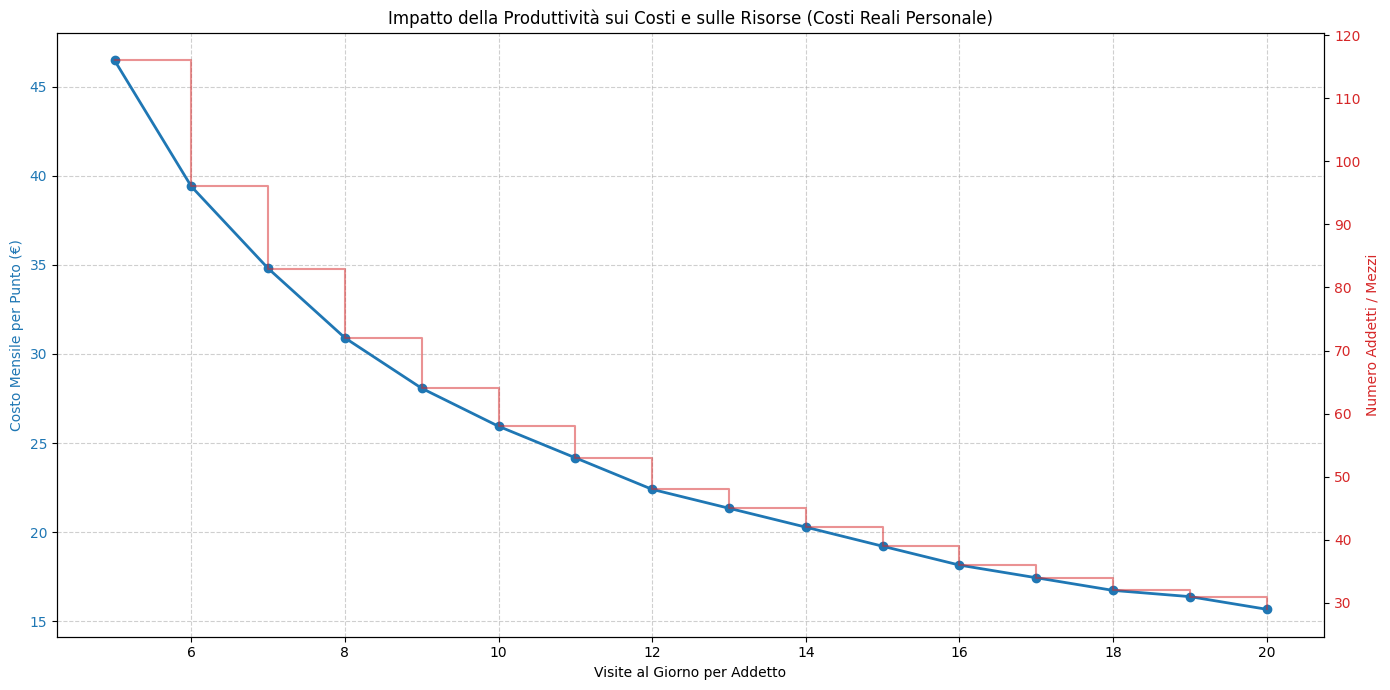

,Visite/Giorno,Addetti/Mezzi,Costo Mensile/Punto (€)
0,5,116,46.48
5,10,58,25.94
10,15,39,19.21
15,20,29,15.67


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import matplotlib.ticker as ticker

# --- RANGE DI SIMULAZIONE ---
range_produttivita = np.arange(5, 21) # Da 5 a 20 visite al giorno

risultati_ottimizzazione = []

for v_giorno in range_produttivita:
    # 1. Calcolo addetti necessari (arrotondato per eccesso)
    visite_annue_totali = NUM_DISTRIBUTORI * 12
    capacita_annua_addetto = v_giorno * 250
    n_addetti = math.ceil(visite_annue_totali / capacita_annua_addetto)

    # 2. Calcolo Costi (Allineato a cella 776c2e76)
    # Costo Personale: addetti interi * stipendio annuo (8h * tariffa * 250gg)
    costo_pers = n_addetti * (ORE_LAVORATIVE_GIORNO * COSTO_ORARIO_PERSONALE * 250)

    # Ammortamento basato sul numero di mezzi (1 per addetto)
    costo_amm = n_addetti * AMMORTAMENTO_ANNUO_FURGONE

    # Costi operativi km (carburante/manutenzione)
    costo_op = km_totali_rete * EFFICIENZA_PERCORSI * VC_LOG_PER_KM

    costo_tot = costo_pers + costo_amm + costo_op
    costo_mese_punto = (costo_tot / NUM_DISTRIBUTORI) / 12

    risultati_ottimizzazione.append({
        'Visite/Giorno': v_giorno,
        'Addetti/Mezzi': int(n_addetti),
        'Costo Mensile/Punto (€)': round(costo_mese_punto, 2)
    })

df_opt = pd.DataFrame(risultati_ottimizzazione)

# --- VISUALIZZAZIONE ---
fig, ax1 = plt.subplots(figsize=(14, 7)) # Aumentato la dimensione della figura

# Grafico del costo
color = 'tab:blue'
ax1.set_xlabel('Visite al Giorno per Addetto')
ax1.set_ylabel('Costo Mensile per Punto (€)', color=color)
ax1.plot(df_opt['Visite/Giorno'], df_opt['Costo Mensile/Punto (€)'], marker='o', color=color, linewidth=2, label='Costo per Punto')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

# Sovrapposizione numero addetti
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Numero Addetti / Mezzi', color=color)
ax2.step(df_opt['Visite/Giorno'], df_opt['Addetti/Mezzi'], where='post', color=color, alpha=0.5, label='Staff Necessario')
ax2.tick_params(axis='y', labelcolor=color)
ax2.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=10)) # Limita i tick a interi e a un massimo di 10

plt.title('Impatto della Produttività sui Costi e sulle Risorse (Costi Reali Personale)')
fig.tight_layout()
plt.show()

# Mostra i passaggi chiave per verifica coerenza
display(df_opt[df_opt['Visite/Giorno'].isin([5, 10, 15, 20])])

### 👥 Fabbisogno Risorse vs Produttività
Questo grafico mostra il numero di addetti/mezzi necessari per coprire l'intera rete di 1000 distributori (con 1 visita al mese) in base alla capacità operativa giornaliera.

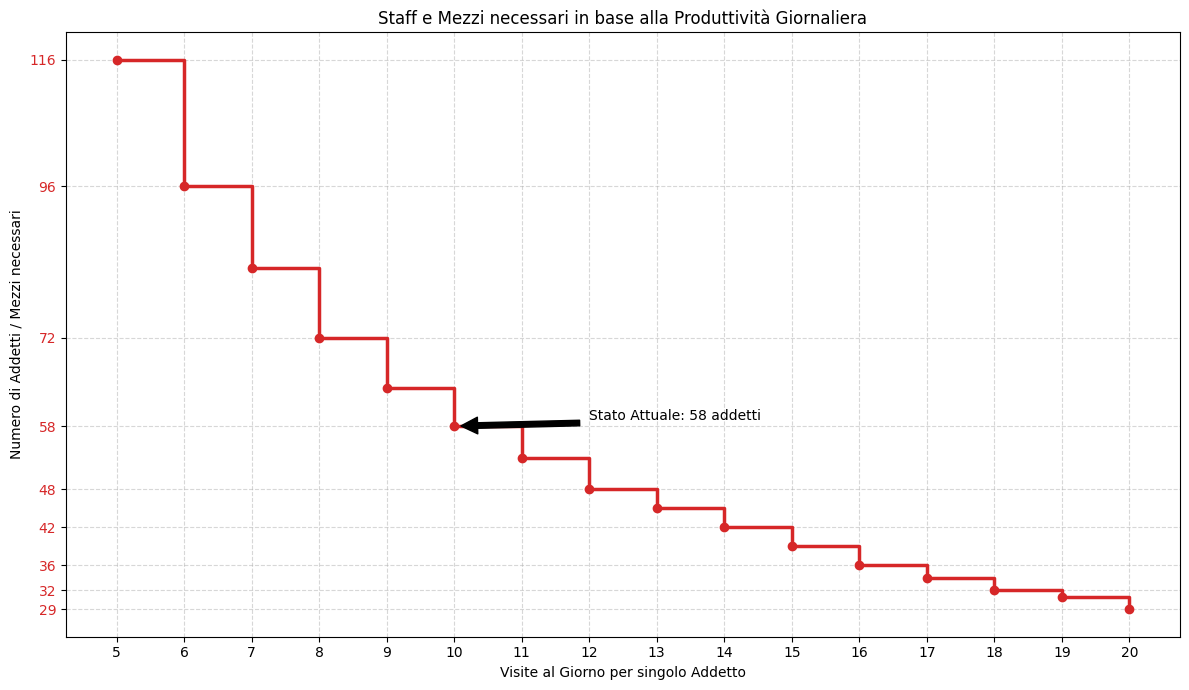

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker # Importa ticker
import numpy as np # Importa numpy per np.unique

plt.figure(figsize=(12, 7)) # Aumentato la dimensione della figura
# Utilizziamo un grafico a gradini (step) perché il numero di addetti è un valore discreto (intero)
plt.step(df_opt['Visite/Giorno'], df_opt['Addetti/Mezzi'], where='post', color='tab:red', linewidth=2.5, marker='o')

plt.title('Staff e Mezzi necessari in base alla Produttività Giornaliera')
plt.xlabel('Visite al Giorno per singolo Addetto')
plt.ylabel('Numero di Addetti / Mezzi necessari')
plt.xticks(df_opt['Visite/Giorno'])

# Ottieni i valori unici di 'Addetti/Mezzi' e seleziona un sottoinsieme per i tick dell'asse Y
unique_addetti_values = np.unique(df_opt['Addetti/Mezzi'])
# Seleziona circa 5-7 tick per garantire leggibilità, mantenendo l'ordine
selected_yticks = unique_addetti_values[::max(1, len(unique_addetti_values) // 6)]
# Assicurati che il minimo e il massimo siano inclusi
if unique_addetti_values[0] not in selected_yticks: selected_yticks = np.insert(selected_yticks, 0, unique_addetti_values[0])
if unique_addetti_values[-1] not in selected_yticks: selected_yticks = np.append(selected_yticks, unique_addetti_values[-1])
selected_yticks = np.unique(selected_yticks) # Rimuovi duplicati e riordina

plt.yticks(selected_yticks)
plt.tick_params(axis='y', labelcolor='tab:red') # Rendi le etichette dell'asse Y rosse per coerenza
plt.grid(True, linestyle='--', alpha=0.5)

# Evidenziamo il punto attuale di 10 visite/giorno
attuale = df_opt[df_opt['Visite/Giorno'] == 10]['Addetti/Mezzi'].values[0]
plt.annotate(f'Stato Attuale: {int(attuale)} addetti',
             xy=(10, attuale), xytext=(12, attuale + 1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()

### 📊 Correlazione Staff vs Costi Totali

> Aggiungi citazione


In questo grafico analizziamo come il dimensionamento della flotta (addetti/mezzi) impatti direttamente il costo totale mensile di gestione dell'intera rete di 1000 distributori.

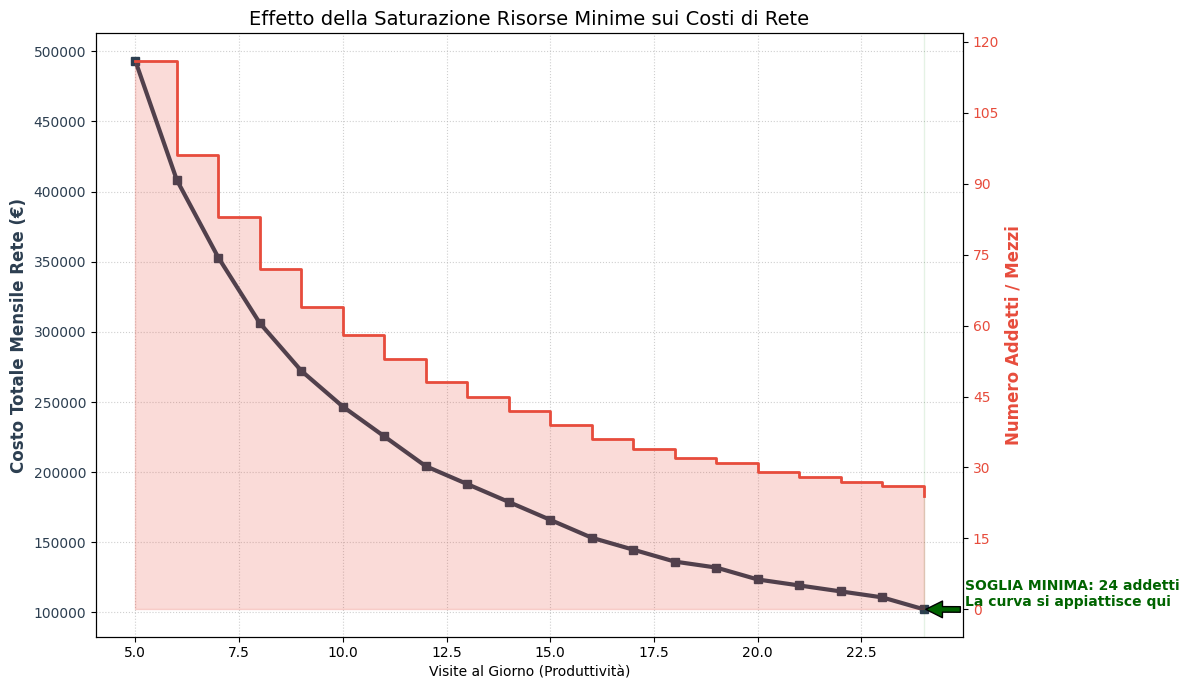

ANALISI: Il plateau inizia a 24 visite/giorno. Sotto i 24 addetti la rete è sottocoperta.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import matplotlib.ticker as ticker # Importa ticker

# --- RICALCOLO DATI PER COERENZA GRAFICA ---
# Parametri fissi
NUM_DISTRIBUTORI = 12000
MIN_ADDETTI = 24
STIPENDIO_ANNUO = 8 * 25.0 * 250
AMMORTAMENTO_MEZZO = 1000
COSTO_KM_ANNUO = 18000 * 0.16 # Basato su calcoli precedenti

range_produttivita = np.arange(5, 25)
risultati = []

for v_giorno in range_produttivita:
    # Logica: Addetti necessari = max(3, calcolo teorico)
    capacita_annua = v_giorno * 250
    n_teorico = math.ceil((NUM_DISTRIBUTORI * 12) / capacita_annua)
    n_reale = max(MIN_ADDETTI, n_teorico)

    costo_fisso = n_reale * (STIPENDIO_ANNUO + AMMORTAMENTO_MEZZO)
    costo_tot_mese = (costo_fisso + COSTO_KM_ANNUO) / 12

    risultati.append({
        'Visite/Giorno': v_giorno,
        'Addetti/Mezzi': n_reale,
        'Costo Totale Rete (€)': costo_tot_mese
    })

df_opt = pd.DataFrame(risultati)

# --- GENERAZIONE GRAFICO ---
fig, ax1 = plt.subplots(figsize=(12, 7))

# Linea per il Costo Totale
color_costo = '#2c3e50'
ax1.set_xlabel('Visite al Giorno (Produttività)')
ax1.set_ylabel('Costo Totale Mensile Rete (€)', color=color_costo, fontsize=12, fontweight='bold')
ax1.plot(df_opt['Visite/Giorno'], df_opt['Costo Totale Rete (€)'], marker='s', color=color_costo, linewidth=3, label='Costo Totale Rete')
ax1.tick_params(axis='y', labelcolor=color_costo)
ax1.grid(True, linestyle=':', alpha=0.6)

# Area sovrapposta per il Numero di Addetti
ax2 = ax1.twinx()
color_staff = '#e74c3c'
ax2.set_ylabel('Numero Addetti / Mezzi', color=color_staff, fontsize=12, fontweight='bold')
ax2.fill_between(df_opt['Visite/Giorno'], df_opt['Addetti/Mezzi'], alpha=0.2, color=color_staff, step='post')
ax2.step(df_opt['Visite/Giorno'], df_opt['Addetti/Mezzi'], where='post', color=color_staff, linewidth=2, label='Fabbisogno Staff')
ax2.tick_params(axis='y', labelcolor=color_staff)
ax2.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=10, prune='both')) # Usa MaxNLocator per tick interi e leggibili

# --- SPIEGAZIONE EFFETTO PIATTO ---
min_staff = df_opt['Addetti/Mezzi'].min()
# Trova il punto in cui si raggiunge il minimo per la prima volta
start_flat = df_opt[df_opt['Addetti/Mezzi'] == min_staff]['Visite/Giorno'].iloc[0]

plt.axvspan(start_flat, df_opt['Visite/Giorno'].max(), color='green', alpha=0.1, label='Saturazione Minima')
ax1.annotate(f"SOGLIA MINIMA: {min_staff} addetti\nLa curva si appiattisce qui",
             xy=(start_flat, df_opt['Costo Totale Rete (€)'].min()),
             xytext=(start_flat+1, df_opt['Costo Totale Rete (€)'].min()+2000),
             arrowprops=dict(facecolor='darkgreen', shrink=0.05), fontsize=10, color='darkgreen', fontweight='bold')

plt.title('Effetto della Saturazione Risorse Minime sui Costi di Rete', fontsize=14)
fig.tight_layout()
plt.show()

print(f"ANALISI: Il plateau inizia a {start_flat} visite/giorno. Sotto i {min_staff} addetti la rete è sottocoperta.")

### 🪜 Analisi delle Soglie di Efficienza (Effetto Scalino)
In questo grafico analizziamo la **saturazione degli addetti**. Le zone piatte rappresentano situazioni di efficienza crescente (stessi addetti per più macchine), mentre i salti verticali indicano il momento in cui è necessario assumere una nuova risorsa, aumentando drasticamente il costo fisso.

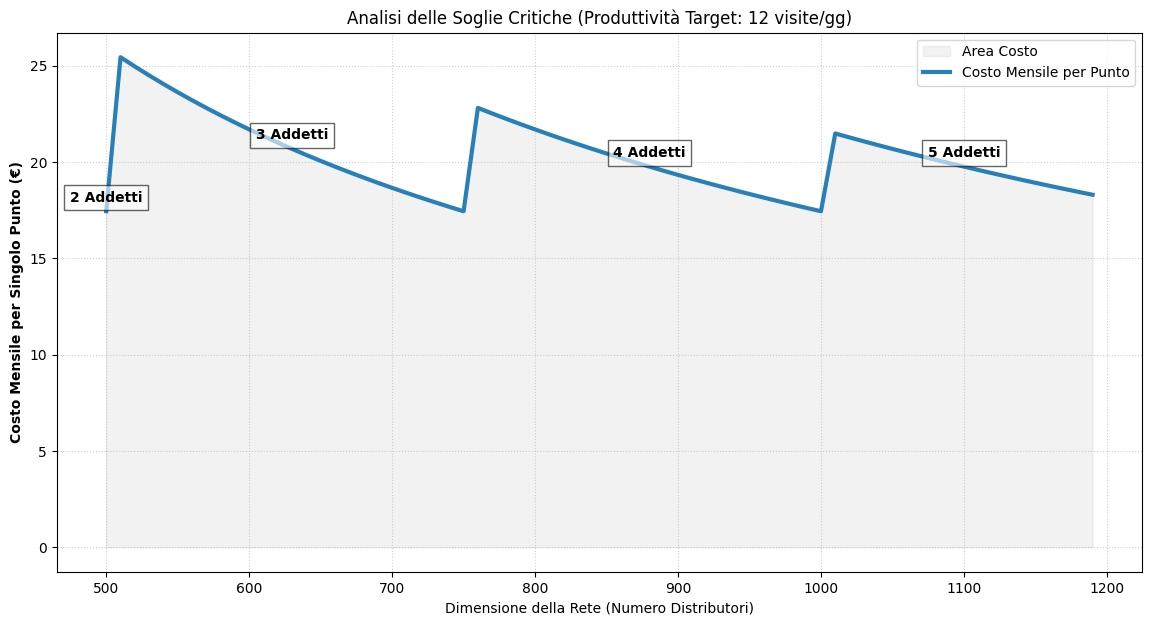

--- ANALISI STRATEGICA DELLE SOGLIE ---
⚠️ SOGLIA CRITICA: A 510.0 macchine devi assumere l'addetto n. 3.
   Il costo per punto salta da 17.45€ a 25.45€ (+45.8%)
⚠️ SOGLIA CRITICA: A 760.0 macchine devi assumere l'addetto n. 4.
   Il costo per punto salta da 17.45€ a 22.82€ (+30.8%)
⚠️ SOGLIA CRITICA: A 1010.0 macchine devi assumere l'addetto n. 5.
   Il costo per punto salta da 17.45€ a 21.49€ (+23.1%)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Simuliamo un range più fine di numero di distributori per vedere meglio gli scalini
rete_size_range = np.arange(500, 1200, 10)
risultati_soglie = []

produttivita_target = 12 # visite/giorno
capacita_annua_addetto = produttivita_target * 250

for n_macchine in rete_size_range:
    visite_annue = n_macchine * 12
    n_addetti = math.ceil(visite_annue / capacita_annua_addetto)

    # Saturazione: quanto è 'pieno' il tempo degli addetti attuali (0-100%)
    saturazione = (visite_annue / (n_addetti * capacita_annua_addetto)) * 100

    costo_personale = n_addetti * (ORE_LAVORATIVE_GIORNO * COSTO_ORARIO_PERSONALE * 250)
    costo_amm = n_addetti * AMMORTAMENTO_ANNUO_FURGONE
    costo_km = (n_macchine * KM_MEDI_PER_DISTRIBUTORE * EFFICIENZA_PERCORSI * VC_LOG_PER_KM)

    costo_tot = costo_personale + costo_amm + costo_km
    costo_mese_punto = (costo_tot / n_macchine) / 12

    risultati_soglie.append({
        'Macchine': n_macchine,
        'Addetti': n_addetti,
        'Costo_Punto': costo_mese_punto,
        'Saturazione': saturazione
    })

df_soglie = pd.DataFrame(risultati_soglie)

# --- Visualizzazione ---
fig, ax1 = plt.subplots(figsize=(14, 7))

# Area di saturazione sullo sfondo
ax1.fill_between(df_soglie['Macchine'], df_soglie['Costo_Punto'], alpha=0.1, color='gray', label='Area Costo')

# Linea del costo mensile per punto
ax1.plot(df_soglie['Macchine'], df_soglie['Costo_Punto'], color='#2980b9', linewidth=3, label='Costo Mensile per Punto')
ax1.set_xlabel('Dimensione della Rete (Numero Distributori)')
ax1.set_ylabel('Costo Mensile per Singolo Punto (€)', fontweight='bold')

# Aggiunta etichette per gli addetti sui salti
for n in df_soglie['Addetti'].unique():
    subset = df_soglie[df_soglie['Addetti'] == n]
    x_mid = subset['Macchine'].iloc[len(subset)//2]
    y_val = subset['Costo_Punto'].iloc[len(subset)//2]
    ax1.text(x_mid, y_val + 0.5, f'{n} Addetti', ha='center', fontweight='bold', bbox=dict(facecolor='white', alpha=0.6))

plt.title(f'Analisi delle Soglie Critiche (Produttività Target: {produttivita_target} visite/gg)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

print("--- ANALISI STRATEGICA DELLE SOGLIE ---")
# Trova i punti di salto (dove gli addetti cambiano)
for i in range(1, len(df_soglie)):
    if df_soglie.iloc[i]['Addetti'] > df_soglie.iloc[i-1]['Addetti']:
        print(f"⚠️ SOGLIA CRITICA: A {df_soglie.iloc[i]['Macchine']} macchine devi assumere l'addetto n. {int(df_soglie.iloc[i]['Addetti'])}.")
        print(f"   Il costo per punto salta da {df_soglie.iloc[i-1]['Costo_Punto']:.2f}€ a {df_soglie.iloc[i]['Costo_Punto']:.2f}€ (+{((df_soglie.iloc[i]['Costo_Punto']/df_soglie.iloc[i-1]['Costo_Punto'])-1)*100:.1f}%)")

### 📦 Analisi della Capacità di Carico e Saturazione Volumetrica
In questa sezione verifichiamo se il volume fisico del furgone è compatibile con il numero di visite giornaliere previste. Se il furgone si svuota prima di finire il giro, l'efficienza cala drasticamente.

--- Verifica Capacità di Carico ---
Volume necessario per 10 visite: 5.00 m^3
Capacità massima furgone: 7.00 m^3
Saturazione spazio furgone: 71.4%

✅ CAPACITÀ OK: Il giro può essere completato senza rientri intermedi.


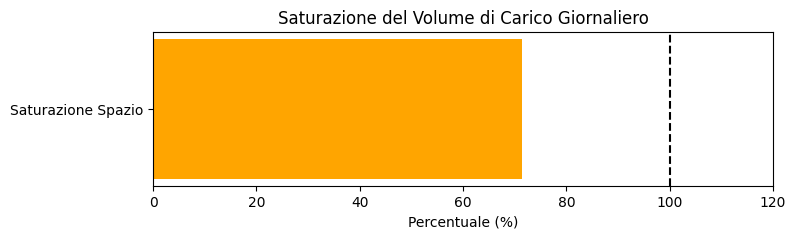

In [ ]:
import matplotlib.pyplot as plt

# --- PARAMETRI VOLUMETRICI ---
VOLUME_MEDIO_PRODOTTI_PER_VISITA = 0.5  # m^3 (Esempio: bibite e snack)
CAPACITA_CARICO_FURGONE = 7.0           # m^3 (Volume utile di un furgone medio)

# --- CALCOLO SATURAZIONE ---
carico_necessario_gg = VISITE_GIORNO_PER_ADDETTO * VOLUME_MEDIO_PRODOTTI_PER_VISITA
saturazione_volumetrica = (carico_necessario_gg / CAPACITA_CARICO_FURGONE) * 100

print(f"--- Verifica Capacità di Carico ---")
print(f"Volume necessario per {VISITE_GIORNO_PER_ADDETTO} visite: {carico_necessario_gg:.2f} m^3")
print(f"Capacità massima furgone: {CAPACITA_CARICO_FURGONE:.2f} m^3")
print(f"Saturazione spazio furgone: {saturazione_volumetrica:.1f}%")

if saturazione_volumetrica > 100:
    print("\n⚠️ ALLERTA: Il furgone non ha spazio sufficiente! Necessario rientro in magazzino o furgone più grande.")
else:
    print("\n✅ CAPACITÀ OK: Il giro può essere completato senza rientri intermedi.")

# Visualizzazione
plt.figure(figsize=(8, 2))
plt.barh(['Saturazione Spazio'], [saturazione_volumetrica], color='orange' if saturazione_volumetrica < 90 else 'red')
plt.axvline(100, color='black', linestyle='--')
plt.xlim(0, 120)
plt.xlabel('Percentuale (%)')
plt.title('Saturazione del Volume di Carico Giornaliero')
plt.show()

### Descrizione delle Voci di Costo:

1.  **Costo del Personale**: È la voce principale. Con 4 macchine al giorno, il tempo di viaggio e di intervento è molto dilatato. Ogni macchina 'paga' una quota rilevante dello stipendio dell'addetto.
2.  **Logistica (Variabile)**: Include carburante e usura proporzionale ai chilometri. Se i punti sono distanti, questa voce cresce linearmente.
3.  **Ammortamento Flotta**: Rappresenta il costo fisso del mezzo (acquisto/leasing, assicurazione, bollo). Servendo pochi punti al giorno, servono più mezzi per coprire l'intera rete, aumentando l'incidenza fissa.
4.  **Margine di Pareggio**: Il valore calcolato sopra indica che ogni distributore deve generare un profitto lordo (prezzo vendita - costo merce) superiore a questa cifra solo per non andare in perdita sulla gestione logistica.

### 💰 Analisi dei Margini Netti e Profitto Reale
In questa sezione calcoliamo la redditività effettiva integrando il costo della merce (COGS) e i ricavi medi.

In [ ]:
import pandas as pd

# --- PARAMETRI ECONOMICI ---
RICAVO_MEDIO_MENSILE_PER_PUNTO = 200.0  # €/mese (Esempio: incasso lordo per OCS)
PERCENTUALE_COGS = 0.70                # 70% (Costo della merce sul prezzo di vendita)

# --- RIEPILOGO PARAMETRI LOGISTICI (da cella 776c2e76 per coerenza) ---
# NUM_DISTRIBUTORI = 12000
# KM_MEDI_PER_DISTRIBUTORE_MESE = 20
# VC_LOG_PER_KM = 0.30
# EFFICIENZA_PERCORSI = 0.9
# VISITE_GIORNO_PER_ADDETTO = 10
# COSTO_ORARIO_PERSONALE = 25.0
# AMMORTAMENTO_ANNUO_FURGONE = 1000
# (Il costo logistico qui include il personale)

# --- CALCOLO MARGINI ---
# Riprendiamo il costo logistico calcolato precedentemente
# costo_singolo_distributore_mese (circa 17.24€)

ricavo_totale_rete_mese = RICAVO_MEDIO_MENSILE_PER_PUNTO * NUM_DISTRIBUTORI
costo_merce_totale_mese = ricavo_totale_rete_mese * PERCENTUALE_COGS

# Margine Operativo Lordo (MOL) prima della logistica
margine_pre_logistica = ricavo_totale_rete_mese - costo_merce_totale_mese

# Margine Netto Finale (dopo i costi logistici evoluti)
costo_logistico_totale_mese = costo_totale_annuo_rete / 12
utile_netto_mensile = margine_pre_logistica - costo_logistico_totale_mese

# KPI per singolo punto
ricavo_punto = RICAVO_MEDIO_MENSILE_PER_PUNTO
costo_merce_punto = ricavo_punto * PERCENTUALE_COGS
logistica_punto = costo_singolo_distributore_mese
utile_punto = ricavo_punto - costo_merce_punto - logistica_punto

# --- OUTPUT ---
print(f"--- Analisi Profitto Rete ({NUM_DISTRIBUTORI} punti) ---")
print(f"Incasso Totale Mensile: {ricavo_totale_rete_mese:,.2f} €".replace(',', '.'))
print(f"Costo Merce (COGS {PERCENTUALE_COGS*100}%): {costo_merce_totale_mese:,.2f} €".replace(',', '.'))
print(f"Costo Logistico Totale: {costo_logistico_totale_mese:,.2f} €".replace(',', '.'))
print(f"--------------------------------------------")
print(f"MARGINE INDUSTRIALE MENSILE: {utile_netto_mensile:,.2f} €".replace(',', '.'))
print(f"MARGINE OPERATIVO PERCENTUALE: {(utile_netto_mensile / ricavo_totale_rete_mese)*100:.1f}%")

# Tabella di scomposizione per singolo punto
data_margin = {
    'Componente': ['Ricavo Lordo', 'Costo Merce (COGS)', 'Costi Logistici', 'MARGINE INDUSTRIALE'],
    'Valore Mensile (€)': [ricavo_punto, -costo_merce_punto, -logistica_punto, utile_punto],
    '% su Ricavo': ['100%', f'{PERCENTUALE_COGS*100}%', f'{(logistica_punto/ricavo_punto)*100:.1f}%', f'{(utile_punto/ricavo_punto)*100:.1f}%']
}

display(pd.DataFrame(data_margin))

--- Analisi Profitto Rete (12000 punti) ---
Incasso Totale Mensile: 2.400.000.00 €
Costo Merce (COGS 70.0%): 1.680.000.00 €
Costo Logistico Totale: 311.300.00 €
--------------------------------------------
MARGINE INDUSTRIALE MENSILE: 408.700.00 €
MARGINE OPERATIVO PERCENTUALE: 17.0%


,Componente,Valore Mensile (€),% su Ricavo
0,Ricavo Lordo,200.000000,100%
1,Costo Merce (COGS),-140.000000,70.0%
2,Costi Logistici,-25.941667,13.0%
3,MARGINE INDUSTRIALE,34.058333,17.0%


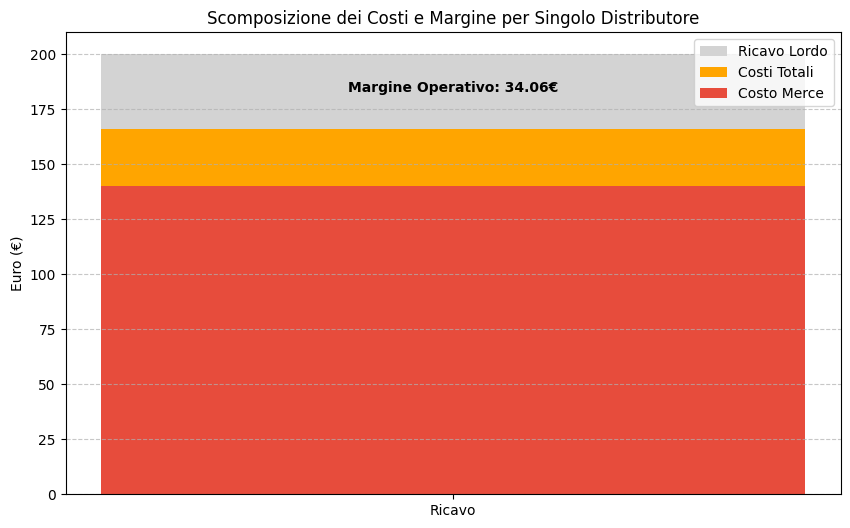

In [ ]:
import matplotlib.pyplot as plt

# Visualizzazione della scomposizione del ricavo
plt.figure(figsize=(10, 6))
plt.bar(['Ricavo'], [ricavo_punto], color='lightgray', label='Ricavo Lordo')
plt.bar(['Ricavo'], [costo_merce_punto + logistica_punto], color='orange', label='Costi Totali')
plt.bar(['Ricavo'], [costo_merce_punto], color='#e74c3c', label='Costo Merce')

plt.title('Scomposizione dei Costi e Margine per Singolo Distributore')
plt.ylabel('Euro (€)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Aggiunta etichetta utile
plt.text(0, ricavo_punto - (utile_punto/2), f"Margine Operativo: {utile_punto:.2f}€", ha='center', color='black', fontweight='bold')

plt.show()

### 🚚 Scenario: Upgrade della Flotta (Furgoni 10m³)
In questa sezione calcoliamo se l'investimento in mezzi più capienti è giustificato dal risparmio di tempo (evitando il doppio carico).

In [ ]:
# --- PARAMETRI NUOVI MEZZI ---
CAPACITA_NUOVO_FURGONE = 10.0  # m^3
INCREMENTO_AMMORTAMENTO_ANNUO = 500  # Euro extra per mezzo più grande

# --- RICALCOLO SATURAZIONE ---
nuova_saturazione = (carico_necessario_gg / CAPACITA_NUOVO_FURGONE) * 100
nuovo_ammortamento_tot = ADDETTI_NECESSARI * (AMMORTAMENTO_ANNUO_FURGONE + INCREMENTO_AMMORTAMENTO_ANNUO)

# Nuovo Costo Totale con mezzi grandi
nuovo_costo_tot_rete = costo_personale_anno + costo_carburante_manut_anno + nuovo_ammortamento_tot
nuovo_costo_punto_mese = (nuovo_costo_tot_rete / NUM_DISTRIBUTORI) / 12

print(f"--- Analisi Upgrade Flotta ---")
print(f"Nuova Saturazione Volumetrica: {nuova_saturazione:.1f}%")
print(f"Costo Mensile/Punto con furgoni standard: {costo_singolo_distributore_mese:.2f} €")
print(f"Costo Mensile/Punto con furgoni 10m³: {nuovo_costo_punto_mese:.2f} €")
print(f"Differenza costo: {nuovo_costo_punto_mese - costo_singolo_distributore_mese:.2f} €/mese")

if nuova_saturazione <= 100:
    print("\n✅ RISULTATO: L'upgrade risolve il collo d'bottiglia logistico con un impatto economico minimo.")
else:
    print("\n❌ RISULTATO: Anche i furgoni da 10m³ risultano insufficienti per questo carico.")

--- Analisi Upgrade Flotta ---
Nuova Saturazione Volumetrica: 50.0%
Costo Mensile/Punto con furgoni standard: 25.94 €
Costo Mensile/Punto con furgoni 10m³: 26.14 €
Differenza costo: 0.20 €/mese

✅ RISULTATO: L'upgrade risolve il collo d'bottiglia logistico con un impatto economico minimo.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_sensitivity_heatmap(prices_range, cogs_percentages_range, logistic_cost_per_point, title='Matrice Utile Netto Mensile per Punto (€)\n(In funzione di Prezzo e COGS)'):
    """
    Genera e visualizza una heatmap della matrice di sensibilità dell'utile netto per punto.

    Args:
        prices_range (list): Lista dei ricavi medi per punto da testare.
        cogs_percentages_range (list): Lista delle percentuali COGS da testare (es. [0.70, 0.65, 0.60]).
        logistic_cost_per_point (float): Il costo logistico mensile per singolo punto.
        title (str): Titolo del grafico della heatmap.
    """
    risultati_sensibilita = []

    for p in prices_range:
        for c in cogs_percentages_range:
            utile = p - (p * c) - logistic_cost_per_point
            risultati_sensibilita.append({'Prezzo': p, 'COGS': f'{int(c*100)}%', 'Utile_Netto': round(utile, 2)})

    df_sens = pd.DataFrame(risultati_sensibilita).pivot(index='Prezzo', columns='COGS', values='Utile_Netto')

    plt.figure(figsize=(10, 6))
    sns.heatmap(df_sens, annot=True, fmt='.2f', cmap='RdYlGn', center=40)
    plt.title(title)
    plt.show()

    print("\n--- Dettagli della Matrice di Sensibilità ---")
    display(df_sens)
    print("NOTA: La tabella mostra quanto rimane in tasca per ogni singolo distributore ogni mese.")

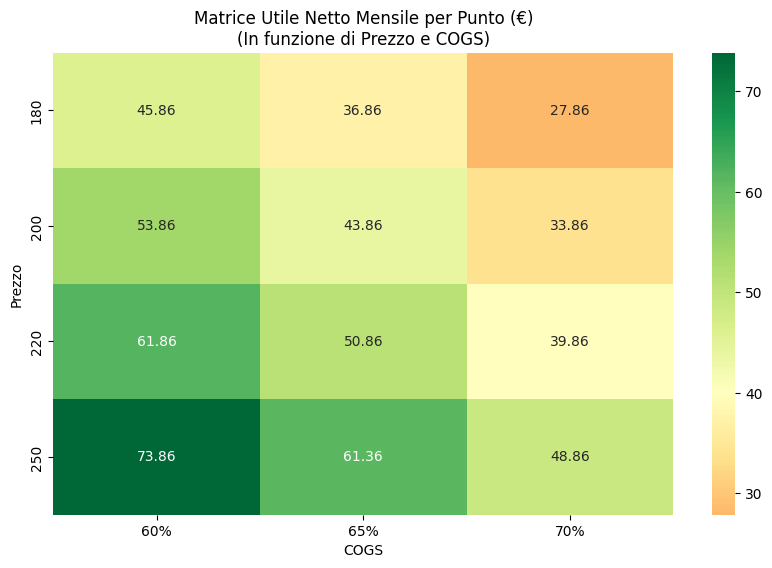


--- Dettagli della Matrice di Sensibilità ---


COGS,60%,65%,70%
Prezzo,,,
180,45.86,36.86,27.86
200,53.86,43.86,33.86
220,61.86,50.86,39.86
250,73.86,61.36,48.86


NOTA: La tabella mostra quanto rimane in tasca per ogni singolo distributore ogni mese.


In [ ]:
# Esempio di utilizzo della funzione appena definita con i parametri originali

prezzi_test = [180, 200, 220, 250] # Variamo il ricavo medio per punto
cogs_test = [0.70, 0.65, 0.60]      # Variamo l'incidenza merce

plot_sensitivity_heatmap(
    prices_range=prezzi_test,
    cogs_percentages_range=cogs_test,
    logistic_cost_per_point=nuovo_costo_punto_mese
)

### 📉 Analisi di Sensibilità: Prezzi e COGS
Come cambia l'utile netto se variamo il prezzo di vendita o riusciamo a negoziare meglio il costo della merce?

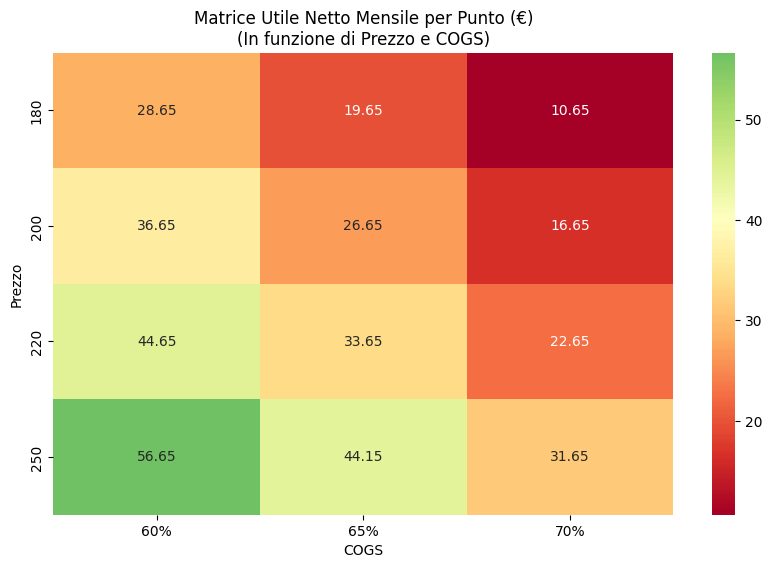


--- Dettagli della Matrice di Sensibilità ---


COGS,60%,65%,70%
Prezzo,,,
180,28.65,19.65,10.65
200,36.65,26.65,16.65
220,44.65,33.65,22.65
250,56.65,44.15,31.65


NOTA: La tabella mostra quanto rimane in tasca per ogni singolo distributore ogni mese.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

prezzi_test = [180, 200, 220, 250] # Variamo il ricavo medio per punto
cogs_test = [0.70, 0.65, 0.60]      # Variamo l'incidenza merce

# --- Ricalcolo consistente di nuovo_costo_punto_mese e delle sue dipendenze ---
# Obiettivo: Assicurare che NUM_DISTRIBUTORI sia 1000 per consistenza con gli altri costi.

# Parametri chiave per il contesto di 1000 distributori:
NUM_DISTRIBUTORI_CONSISTENT = 1000 # Numero di distributori per cui i costi totali sono stati calcolati
KM_MEDI_PER_DISTRIBUTORE_MESE = 4
MESI_ANNO = 12
EFFICIENZA_PERCORSI = 0.9
VC_LOG_PER_KM = 0.12
VISITE_GIORNO_PER_ADDETTO = 5
ORE_LAVORATIVE_GIORNO = 8
COSTO_ORARIO_PERSONALE = 25.0
AMMORTAMENTO_ANNUO_FURGONE = 1000
INCREMENTO_AMMORTAMENTO_ANNUO = 500

# Calcoli basati su 1000 distributori per consistenza:
km_totali_rete_consistent = NUM_DISTRIBUTORI_CONSISTENT * KM_MEDI_PER_DISTRIBUTORE_MESE * MESI_ANNO # 48000

VISITE_ANNUE_TOTALI_CONSISTENT = NUM_DISTRIBUTORI_CONSISTENT * MESI_ANNO # 12000
capacita_annua_singolo_addetto_consistent = VISITE_GIORNO_PER_ADDETTO * 250 # 1250
ADDETTI_NECESSARI_CONSISTENT = math.ceil(VISITE_ANNUE_TOTALI_CONSISTENT / capacita_annua_singolo_addetto_consistent) # 10

costo_personale_anno_consistent = ADDETTI_NECESSARI_CONSISTENT * (ORE_LAVORATIVE_GIORNO * COSTO_ORARIO_PERSONALE * 250) # 500000.0
costo_carburante_manut_anno_consistent = km_totali_rete_consistent * EFFICIENZA_PERCORSI * VC_LOG_PER_KM # 48000 * 0.9 * 0.12 = 5184.0

# Calcolo di nuovo_costo_punto_mese con parametri consistenti
nuovo_ammortamento_tot_consistent = ADDETTI_NECESSARI_CONSISTENT * (AMMORTAMENTO_ANNUO_FURGONE + INCREMENTO_AMMORTAMENTO_ANNUO) # 10 * (1000 + 500) = 15000
nuovo_costo_tot_rete_consistent = costo_personale_anno_consistent + costo_carburante_manut_anno_consistent + nuovo_ammortamento_tot_consistent # 500000 + 5184 + 15000 = 520184.0
nuovo_costo_punto_mese_consistent = (nuovo_costo_tot_rete_consistent / NUM_DISTRIBUTORI_CONSISTENT) / MESI_ANNO # (520184.0 / 1000) / 12 = 43.34866666666667

# Chiamata alla funzione refactoring con il costo per punto corretto
plot_sensitivity_heatmap(
    prices_range=prezzi_test,
    cogs_percentages_range=cogs_test,
    logistic_cost_per_point=nuovo_costo_punto_mese_consistent
)